## Setup

Install dependencies (run once, then restart kernel if prompted).


In [1]:
# Run once. Restart kernel if prompted.
%pip install -q --upgrade pip
%pip install -q pandas requests tqdm python-dateutil rapidfuzz pyyaml scipy matplotlib joblib boto3 sagemaker shap xgboost "scikit-learn==1.4.2" google-cloud-bigquery


Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


## Imports & Configuration

In [2]:
import os
import re
import json
import time
import warnings
from pathlib import Path
from datetime import datetime, timezone

import requests
import pandas as pd
from tqdm.auto import tqdm
from dateutil import parser as dateparser

try:
    from rapidfuzz import fuzz, process
except ImportError:
    fuzz = None
    process = None
    print("rapidfuzz not installed. Name-similarity features will be skipped.")

warnings.filterwarnings("ignore")

BASE_DIR = Path("supply_chain_risk_dataset")
RAW_DIR = BASE_DIR / "raw"
PROCESSED_DIR = BASE_DIR / "processed"
DEPLOY_DIR = Path("sagemaker_deploy")

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
DEPLOY_DIR.mkdir(parents=True, exist_ok=True)

MAX_BENIGN_PACKAGES = 25_000
MAX_PACKAGES_TO_ENRICH = 22_000
MIN_EXPECTED_PER_CLASS = 10_000

REQUEST_SLEEP_SECONDS = 0.05
FORCE_REFETCH = False

# Optional: set a GitHub token to avoid rate limiting during pypi_malregistry collection
GITHUB_TOKEN = os.environ.get("GITHUB_TOKEN", "")
GITHUB_HEADERS = {"Authorization": f"Bearer {GITHUB_TOKEN}"} if GITHUB_TOKEN else {}

S3_BUCKET = ""  # leave blank to use SageMaker default bucket
S3_DATA_PREFIX = "supply-chain-risk"
S3_MODEL_PREFIX = "supply-chain-risk/models"
SKLEARN_VERSION = "1.4-2"
INSTANCE_TYPE = "ml.m5.large"

# Timestamped endpoint names prevent Run All from failing because of old endpoint names.
ENDPOINT_NAME = f"supply-chain-risk-endpoint-{datetime.now().strftime('%Y%m%d-%H%M%S')}"

# Keep False until after your video. Set True and rerun the cleanup cell at the end to delete.
AUTO_DELETE_ENDPOINT_AFTER_TEST = False
ENDPOINT_NAME = f"supply-chain-risk-endpoint-{datetime.now().strftime('%Y%m%d-%H%M%S')}"
AUTO_DELETE_ENDPOINT_AFTER_TEST = False

TODAY = datetime.now(timezone.utc)

print("Data directory:", BASE_DIR.resolve())

Data directory: /home/sagemaker-user/supply_chain_risk_dataset


## Helper Functions

In [3]:
def safe_get_json(url, params=None, headers=None, timeout=60, quiet_404=False):
    """GET a URL and return JSON, or None on failure."""
    try:
        response = requests.get(url, params=params, headers=headers, timeout=timeout)
        if response.status_code == 200:
            return response.json()
        if response.status_code == 404 and quiet_404:
            return None
        print(f"Request failed: {response.status_code} | {url}")
        return None
    except Exception as e:
        print(f"Request error for {url}: {e}")
        return None


def normalize_package_name(name):
    """PEP 503 normalization: lowercase, collapse -, _, . into -."""
    if not isinstance(name, str):
        return None
    name = name.strip().lower()
    name = re.sub(r"[-_.]+", "-", name)
    return name if name else None


def save_csv(df, filename):
    path = PROCESSED_DIR / filename
    df.to_csv(path, index=False)
    print(f"Saved {len(df):,} rows -> {path}")
    return path


def save_json(data, filename):
    path = RAW_DIR / filename
    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2)
    print(f"Saved JSON -> {path}")
    return path


def github_tree(owner, repo, branch="main"):
    url = f"https://api.github.com/repos/{owner}/{repo}/git/trees/{branch}?recursive=1"
    data = safe_get_json(url, headers=GITHUB_HEADERS)
    if data is None:
        return []
    return data.get("tree", [])


def load_raw_github_file(owner, repo, branch, path):
    url = f"https://raw.githubusercontent.com/{owner}/{repo}/{branch}/{path}"
    return safe_get_json(url, headers=GITHUB_HEADERS)


# Malicious Package Labels

Builds `label = 1` rows from two public threat intel sources: DataDog and pypi_malregistry.


## DataDog Dataset


In [4]:
def load_datadog_manifest(ecosystem="pypi"):
    urls_to_try = [
        f"https://raw.githubusercontent.com/DataDog/malicious-software-packages-dataset/main/samples/{ecosystem}/manifest.json",
        f"https://raw.githubusercontent.com/DataDog/malicious-software-packages-dataset/master/samples/{ecosystem}/manifest.json",
    ]

    for url in urls_to_try:
        data = safe_get_json(url)
        if data is not None:
            print(f"Loaded DataDog manifest for {ecosystem}: {len(data):,} entries")
            save_json(data, f"datadog_{ecosystem}_manifest.json")
            return data

    print(f"Could not load DataDog manifest for {ecosystem}")
    return {}


def datadog_manifest_to_df(manifest, ecosystem):
    rows = []
    for package_name, affected_versions in manifest.items():
        normalized = normalize_package_name(package_name)
        if not normalized:
            continue

        if affected_versions is None:
            malicious_type = "malicious_intent"
            versions = []
        elif isinstance(affected_versions, list):
            malicious_type = "compromised_versions"
            versions = affected_versions
        else:
            malicious_type = "unknown"
            versions = []

        rows.append({
            "package_name": package_name,
            "normalized_name": normalized,
            "ecosystem": ecosystem,
            "label": 1,
            "label_source": "datadog_malicious_software_packages_dataset",
            "malicious_type": malicious_type,
            "affected_versions": json.dumps(versions)
        })

    return pd.DataFrame(rows)


datadog_pypi_manifest = load_datadog_manifest("pypi")
datadog_npm_manifest = load_datadog_manifest("npm")

datadog_pypi_df = datadog_manifest_to_df(datadog_pypi_manifest, "pypi")
datadog_npm_df = datadog_manifest_to_df(datadog_npm_manifest, "npm")

datadog_malicious_df = pd.concat([datadog_pypi_df, datadog_npm_df], ignore_index=True)
datadog_malicious_df.head()


Loaded DataDog manifest for pypi: 1,833 entries
Saved JSON -> supply_chain_risk_dataset/raw/datadog_pypi_manifest.json
Loaded DataDog manifest for npm: 45,669 entries
Saved JSON -> supply_chain_risk_dataset/raw/datadog_npm_manifest.json


,package_name,normalized_name,ecosystem,label,label_source,malicious_type,affected_versions
0,0wneg,0wneg,pypi,1,datadog_malicious_software_packages_dataset,malicious_intent,[]
1,1337test,1337test,pypi,1,datadog_malicious_software_packages_dataset,malicious_intent,[]
2,282828282828282828,282828282828282828,pypi,1,datadog_malicious_software_packages_dataset,malicious_intent,[]
3,EZBEAMER,ezbeamer,pypi,1,datadog_malicious_software_packages_dataset,malicious_intent,[]
4,EZBEAMSW,ezbeamsw,pypi,1,datadog_malicious_software_packages_dataset,malicious_intent,[]


## pypi_malregistry


In [5]:
def collect_pypi_malregistry_labels(max_paths=20000):
        # Save results to RAW_DIR so a successful fetch is reused if the GitHub
    # API is temporarily unavailable on the next run.
    _local_cache = RAW_DIR / "pypi_malregistry_labels.csv"

        # GitHub's recursive-tree API occasionally returns 504 or an empty payload.
    # Retry up to 3 times with exponential backoff before falling back to the
    # local cache written by a previous successful run.
    tree = []
    _delay = 5  # seconds between retries
    for _attempt in range(3):
        tree = github_tree("lxyeternal", "pypi_malregistry", "main")
        if tree:
            break
        if _attempt < 2:
            print(f"pypi_malregistry tree empty (attempt {_attempt + 1}/3). "
                  f"Retrying in {_delay}s...")
            time.sleep(_delay)
            _delay *= 2  # 5 → 10 → 20 s

    print(f"pypi_malregistry tree entries: {len(tree):,}")

    rows = []
    archive_exts = (".zip", ".tar.gz", ".tgz", ".whl", ".tar.bz2")

    for item in tree[:max_paths]:
        path = item.get("path", "")
        if item.get("type") != "blob":
            continue
        if not path.lower().endswith(archive_exts):
            continue

        parts = path.split("/")
        if len(parts) >= 2:
            package_name = parts[0]
        else:
            continue

        normalized = normalize_package_name(package_name)
        if not normalized:
            continue

        version = parts[1] if len(parts) >= 3 else None

        rows.append({
            "package_name": package_name,
            "normalized_name": normalized,
            "ecosystem": "pypi",
            "label": 1,
            "label_source": "pypi_malregistry",
            "malicious_type": "malicious_pypi_package",
            "affected_versions": json.dumps([version] if version else []),
            "repo_path": path
        })

    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.drop_duplicates(subset=["normalized_name", "ecosystem"])
        # Save for next-run fallback
        df.to_csv(_local_cache, index=False)
        print(f"Saved {len(df):,} rows to local cache: {_local_cache}")

    elif _local_cache.exists():
        # GitHub API returned nothing — use the last known-good snapshot
        df = pd.read_csv(_local_cache)
        print(f"WARNING: GitHub API returned no data. "
              f"Using local fallback cache ({len(df):,} rows) from {_local_cache}")
    else:
        print("WARNING: GitHub API returned no data and no local cache exists. "
              "pypi_malregistry will contribute 0 malicious labels this run.\n"
              "This will cause class imbalance. Re-run once network access is restored.")

    print(f"pypi_malregistry malicious package rows: {len(df):,}")
    return df


pypi_malregistry_df = collect_pypi_malregistry_labels()
pypi_malregistry_df.head()


pypi_malregistry tree entries: 33,631
Saved 5,939 rows to local cache: supply_chain_risk_dataset/raw/pypi_malregistry_labels.csv
pypi_malregistry malicious package rows: 5,939


,package_name,normalized_name,ecosystem,label,label_source,malicious_type,affected_versions,repo_path
0,0x000testqwe,0x000testqwe,pypi,1,pypi_malregistry,malicious_pypi_package,"[""5.20.4""]",0x000testqwe/5.20.4/0x000testqwe-5.20.4.tar.gz
1,10Cent10,10cent10,pypi,1,pypi_malregistry,malicious_pypi_package,"[""999.0.4""]",10Cent10/999.0.4/10Cent10-999.0.4.tar.gz
2,10Cent11,10cent11,pypi,1,pypi_malregistry,malicious_pypi_package,"[""999.0.4""]",10Cent11/999.0.4/10Cent11-999.0.4.tar.gz
3,11cent,11cent,pypi,1,pypi_malregistry,malicious_pypi_package,"[""999.0.0""]",11cent/999.0.0/11Cent-999.0.0.tar.gz
8,123bla,123bla,pypi,1,pypi_malregistry,malicious_pypi_package,"[""0.0.1""]",123bla/0.0.1/123bla-0.0.1-py3-none-any.whl


## Combine Malicious Labels

In [6]:
malicious_dfs = [
    datadog_malicious_df,
    pypi_malregistry_df
]

malicious_labels_df = pd.concat(
    [df for df in malicious_dfs if df is not None and not df.empty],
    ignore_index=True,
    sort=False
)

if not malicious_labels_df.empty:
    malicious_labels_df["normalized_name"] = malicious_labels_df["package_name"].apply(normalize_package_name)
    malicious_labels_df["ecosystem"] = malicious_labels_df["ecosystem"].fillna("unknown").astype(str).str.lower()

    malicious_labels_df = (
        malicious_labels_df
        .groupby(["normalized_name", "ecosystem"], as_index=False)
        .agg({
            "package_name": "first",
            "label": "max",
            "label_source": lambda x: ";".join(sorted(set(map(str, x)))),
            "malicious_type": lambda x: ";".join(sorted(set(map(str, x)))),
            "affected_versions": lambda x: ";".join(sorted(set(map(str, x.dropna())))) if hasattr(x, "dropna") else "",
        })
    )
else:
    malicious_labels_df = pd.DataFrame(columns=[
        "normalized_name", "ecosystem", "package_name", "label", "label_source",
        "malicious_type", "affected_versions"
    ])

save_csv(malicious_labels_df, "malicious_labels.csv")
malicious_labels_df.head()


Saved 52,709 rows -> supply_chain_risk_dataset/processed/malicious_labels.csv


,normalized_name,ecosystem,package_name,label,label_source,malicious_type,affected_versions
0,000webhost-admin,npm,000webhost-admin,1,datadog_malicious_software_packages_dataset,malicious_intent,[]
1,000webhost-analytics,npm,000webhost-analytics,1,datadog_malicious_software_packages_dataset,malicious_intent,[]
2,000webhost-api,npm,000webhost-api,1,datadog_malicious_software_packages_dataset,malicious_intent,[]
3,000webhost-api-client,npm,000webhost-api-client,1,datadog_malicious_software_packages_dataset,malicious_intent,[]
4,000webhost-auth,npm,000webhost-auth,1,datadog_malicious_software_packages_dataset,malicious_intent,[]


# Benign Package Labels *(v7 - bypassed)*

In **v7** the benign label collection step is not needed.
Benign packages come directly from the pre-built BigQuery balanced dataset
(`data/bq_balanced_dataset.csv`) loaded in the next section.

Cells 14-16 below create lightweight stubs so later cells that reference
`benign_labels_df` or `label_df` do not raise a `NameError`.


In [7]:
# v7: benign labels come from BigQuery -- no network download needed.
# Stub keeps variable names valid for any downstream cell that checks them.

benign_labels_df = pd.DataFrame(
    columns=["package_name", "normalized_name", "label", "label_source"]
)
print("v7: benign_labels_df stub created."
      " Real benign data is loaded from data/bq_balanced_dataset.csv in cell 18.")


v7: benign_labels_df stub created. Real benign data is loaded from data/bq_balanced_dataset.csv in cell 18.


# Combined Label Table *(v7 - bypassed)*

In **v7** the combined `label_df` is superseded by the BigQuery balanced dataset.
The stub below keeps `label_df` defined so nothing downstream raises a `NameError`.


In [8]:
# v7: label_df stub -- real training data comes from bq_balanced_dataset.csv.

label_df = pd.DataFrame(
    columns=["package_name", "normalized_name", "label", "label_source"]
)
print(f"v7: label_df stub created ({len(label_df)} rows)."
      " Real training data is in data/bq_balanced_dataset.csv (cell 18).")


v7: label_df stub created (0 rows). Real training data is in data/bq_balanced_dataset.csv (cell 18).


# PyPI Metadata — BigQuery Balanced Dataset (Zero Leakage)

Loads the **pre-built 14,006-row balanced dataset** fetched from
`bigquery-public-data.pypi.distribution_metadata`:

- **7,003 malicious** packages (all known OpenSSF + DataDog PyPI threats)
- **7,003 benign** packages (randomly sampled, confirmed on PyPI)
- **Zero NaN** — real BigQuery metadata for every row
- **No leaky features** — `pypi_found`, `download_count_30d`, `typosquatting_risk`,
  `name_similarity_to_popular_package` are all absent

If you want to re-fetch from BigQuery, run `fetch_pypi_bigquery_expanded.py` first.


In [9]:
import numpy as np

# ── Load the leakage-free BigQuery balanced dataset ──────────────────────
_bq_csv = Path("data/bq_balanced_dataset.csv")

if not _bq_csv.exists():
    raise FileNotFoundError(
        f"Missing {_bq_csv}.\n"
        "Run fetch_pypi_bigquery_expanded.py to download it:\n"
        "  gcloud config set project aai540\n"
        "  python fetch_pypi_bigquery_expanded.py\n"
    )

bq_df = pd.read_csv(_bq_csv, low_memory=False)
bq_df["label"] = bq_df["label"].astype(int)

print(f"Loaded BigQuery balanced dataset: {len(bq_df):,} rows")
print(f"  Benign    (0): {(bq_df['label']==0).sum():,}")
print(f"  Malicious (1): {(bq_df['label']==1).sum():,}")
print(f"  NaN cells    : {bq_df.isnull().sum().sum():,}")
print(f"  Columns      : {list(bq_df.columns)}")

# Metadata columns present in the BQ dataset
BQ_META_COLS = [
    "summary_length", "description_length", "requires_python_present",
    "author_present", "author_email_present", "maintainer_present",
    "maintainer_email_present", "license_present", "homepage_present",
    "release_count", "package_age_days", "days_since_latest_release",
]
BQ_META_COLS = [c for c in BQ_META_COLS if c in bq_df.columns]
print(f"\nMetadata features available: {BQ_META_COLS}")


Loaded BigQuery balanced dataset: 14,006 rows
  Benign    (0): 7,003
  Malicious (1): 7,003
  NaN cells    : 0
  Columns      : ['normalized_name', 'package_name', 'summary_length', 'description_length', 'requires_python_present', 'author_present', 'author_email_present', 'maintainer_present', 'maintainer_email_present', 'license_present', 'homepage_present', 'release_count', 'package_age_days', 'days_since_latest_release', 'label', 'label_source', 'name_length', 'name_entropy', 'digit_count', 'has_digits', 'hyphen_count', 'underscore_count', 'dot_count', 'starts_with_py', 'ends_with_py', 'all_lowercase', 'has_special_chars', 'summary_length_missing', 'description_length_missing', 'requires_python_present_missing', 'author_present_missing', 'author_email_present_missing', 'maintainer_present_missing', 'maintainer_email_present_missing', 'license_present_missing', 'homepage_present_missing', 'release_count_missing', 'package_age_days_missing', 'days_since_latest_release_missing']

Metad

# Name Features

Engineered from the package name string alone — available for every package.
These features capture structural signals that correlate with malicious intent
(e.g., high character entropy, unusual digit patterns, very short names).

> **Note:** `name_similarity_to_popular_package` and `typosquatting_risk` are
> **excluded** from v7 — they require comparing against live top-package lists
> and were identified as potential leaky features.


## Name-only Features

Engineered from the package name string alone — available for every package regardless of whether it's still on PyPI.


In [10]:
import math
import string


def name_entropy(name: str) -> float:
    """Shannon entropy of a string — high entropy = more random-looking."""
    if not name:
        return 0.0
    freq = {c: name.count(c) / len(name) for c in set(name)}
    return float(-sum(p * math.log2(p) for p in freq.values()))


def add_name_features(df: pd.DataFrame) -> pd.DataFrame:
    """Name-derived features that work even when PyPI returns 404."""
    df = df.copy()
    names = df["package_name"].fillna("").astype(str)

    df["name_length"]          = names.str.len()
    df["name_entropy"]         = names.apply(name_entropy).astype(float).round(4)
    df["digit_count"]          = names.apply(lambda n: sum(c.isdigit() for c in n))
    df["has_digits"]           = (df["digit_count"] > 0).astype(int)
    df["hyphen_count"]         = names.str.count("-")
    df["underscore_count"]     = names.str.count("_")
    df["dot_count"]            = names.str.count(r"\.")
    df["starts_with_py"]       = names.str.lower().str.startswith("py").astype(int)
    df["ends_with_py"]         = names.str.lower().str.endswith("py").astype(int)
    df["all_lowercase"]        = names.apply(lambda n: int(n == n.lower()) if n else 0)
    df["has_special_chars"]    = names.apply(
        lambda n: int(any(c not in string.ascii_letters + string.digits + "-_." for c in n))
    )

    return df


# Apply to label_df so every row (malicious + benign) gets name features.
label_df = add_name_features(label_df)

print("Name features added. Sample:")
name_feat_cols = [
    "package_name", "label",
    "name_length", "name_entropy", "digit_count", "has_digits",
    "hyphen_count", "underscore_count", "starts_with_py",
]
print(label_df[name_feat_cols].head(10).to_string(index=False))


Name features added. Sample:
Empty DataFrame
Columns: [package_name, label, name_length, name_entropy, digit_count, has_digits, hyphen_count, underscore_count, starts_with_py]
Index: []


In [11]:
# add_name_similarity_features() was present in v6 but is EXCLUDED in v7.
# Reason: computing fuzzy similarity against the live top-PyPI list introduces
# temporal leakage (the reference list changes over time) and adds inference
# latency without meaningful AUC gain once NaN-pattern leakage is removed.
#
# The name features in add_name_features() (entropy, length, digit counts, etc.)
# are sufficient and fully leakage-free.
print("Name-similarity features excluded in v7 (leakage-free pipeline). Skipping.")


Name-similarity features excluded in v7 (leakage-free pipeline). Skipping.


# Build ML Dataset

In [12]:
# ── Build the ML dataset from the BigQuery balanced dataset ─────────────
# Applies name features on top of the BQ metadata columns.

import math, string

# name features are already defined in cell 21 (add_name_features)
ml_df = add_name_features(bq_df.copy())

# Ensure all metadata columns are numeric
for col in BQ_META_COLS:
    ml_df[col] = pd.to_numeric(ml_df[col], errors="coerce")

print(f"ML dataset ready: {len(ml_df):,} rows")
print(f"  Benign    (0): {(ml_df['label']==0).sum():,}")
print(f"  Malicious (1): {(ml_df['label']==1).sum():,}")
print(f"  NaN cells    : {ml_df.isnull().sum().sum():,}")
print(f"  Columns ({ml_df.shape[1]}): {list(ml_df.columns)}")


ML dataset ready: 14,006 rows
  Benign    (0): 7,003
  Malicious (1): 7,003
  NaN cells    : 0
  Columns (39): ['normalized_name', 'package_name', 'summary_length', 'description_length', 'requires_python_present', 'author_present', 'author_email_present', 'maintainer_present', 'maintainer_email_present', 'license_present', 'homepage_present', 'release_count', 'package_age_days', 'days_since_latest_release', 'label', 'label_source', 'name_length', 'name_entropy', 'digit_count', 'has_digits', 'hyphen_count', 'underscore_count', 'dot_count', 'starts_with_py', 'ends_with_py', 'all_lowercase', 'has_special_chars', 'summary_length_missing', 'description_length_missing', 'requires_python_present_missing', 'author_present_missing', 'author_email_present_missing', 'maintainer_present_missing', 'maintainer_email_present_missing', 'license_present_missing', 'homepage_present_missing', 'release_count_missing', 'package_age_days_missing', 'days_since_latest_release_missing']


# Data Quality Check


In [13]:
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Shape: {ml_df.shape[0]:,} rows x {ml_df.shape[1]} columns")
print(f"\nColumn dtypes:\n{ml_df.dtypes.to_string()}")

# Ensure label is int for all groupby/rename operations below
_df = ml_df.copy()
_df["label"] = _df["label"].astype(int)

print("\n" + "=" * 60)
print("LABEL DISTRIBUTION")
print("=" * 60)
label_counts = _df["label"].value_counts().sort_index()
label_pct = _df["label"].value_counts(normalize=True).sort_index() * 100
label_summary = pd.DataFrame({"count": label_counts, "pct": label_pct.round(2)})
label_summary.index = label_summary.index.map({0: "benign (0)", 1: "malicious (1)"})
print(label_summary.to_string())
imbalance_ratio = label_counts.get(0, 0) / max(label_counts.get(1, 1), 1)
print(f"\nImbalance ratio (benign:malicious): {imbalance_ratio:.1f}:1")

print("\n" + "=" * 60)
print("MISSING VALUES PER COLUMN")
print("=" * 60)
missing = _df.isnull().sum()
missing_pct = (missing / len(_df) * 100).round(2)
missing_df = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_df = missing_df[missing_df["missing_count"] > 0].sort_values("missing_pct", ascending=False)
if missing_df.empty:
    print("No missing values found.")
else:
    print(missing_df.to_string())

print("\n" + "=" * 60)
print("PyPI FOUND RATE")
print("=" * 60)
if "pypi_found" in _df.columns:
    found_by_label = _df.groupby("label")["pypi_found"].agg(["sum", "count"])
    found_by_label["found_pct"] = (found_by_label["sum"] / found_by_label["count"] * 100).round(1)
    found_by_label.index = found_by_label.index.map({0: "benign (0)", 1: "malicious (1)"})
    print(found_by_label.rename(columns={"sum": "found", "count": "total"}).to_string())

print("\n" + "=" * 60)
print("NUMERIC FEATURE STATISTICS BY LABEL")
print("=" * 60)
numeric_feature_cols = [
    "summary_length", "description_length", "release_count",
    "package_age_days", "days_since_latest_release",
    "dependency_count_from_requires_dist", "project_urls_count",
    "download_count_30d", "name_similarity_to_popular_package",
]
numeric_feature_cols = [c for c in numeric_feature_cols if c in _df.columns]

stats_by_label = _df.groupby("label")[numeric_feature_cols].median().T.round(1)
# Rename only columns that actually exist (handles single-class edge case)
col_rename = {k: v for k, v in {0: "median_benign", 1: "median_malicious"}.items() if k in stats_by_label.columns}
stats_by_label = stats_by_label.rename(columns=col_rename)

if "median_benign" in stats_by_label.columns and "median_malicious" in stats_by_label.columns:
    stats_by_label["ratio_mal_vs_ben"] = (
        stats_by_label["median_malicious"] / stats_by_label["median_benign"].replace(0, float("nan"))
    ).round(3)
print(stats_by_label.to_string())

print("\n" + "=" * 60)
print("BINARY FLAG PRESENCE RATES BY LABEL  (mean = % of packages with flag=1)")
print("=" * 60)
binary_cols = [
    "requires_python_present", "author_present", "author_email_present",
    "maintainer_present", "maintainer_email_present",
    "license_present", "homepage_present", "repo_url_present", "typosquatting_risk",
]
binary_cols = [c for c in binary_cols if c in _df.columns]
flag_rates = _df.groupby("label")[binary_cols].mean().T.round(3)
col_rename = {k: v for k, v in {0: "rate_benign", 1: "rate_malicious"}.items() if k in flag_rates.columns}
flag_rates = flag_rates.rename(columns=col_rename)
if "rate_benign" in flag_rates.columns and "rate_malicious" in flag_rates.columns:
    flag_rates["delta"] = (flag_rates["rate_malicious"] - flag_rates["rate_benign"]).round(3)
    print(flag_rates.sort_values("delta").to_string())
else:
    print(flag_rates.to_string())

print("\n" + "=" * 60)
print("FEATURE CORRELATION WITH LABEL (point-biserial)")
print("=" * 60)
corr_cols = numeric_feature_cols + binary_cols
corr_cols = [c for c in corr_cols if c in _df.columns]
corr_series = (
    _df[corr_cols + ["label"]]
    .apply(lambda col: col.corr(_df["label"]) if col.name != "label" else None)
    .dropna()
    .sort_values(key=abs, ascending=False)
    .round(4)
)
print(corr_series.to_string())

print("\n" + "=" * 60)
print("LOW-VARIANCE FEATURE CHECK  (std < 0.01 may be near-constant)")
print("=" * 60)
low_var = _df[corr_cols].std().sort_values()
low_var_cols = low_var[low_var < 0.01]
if low_var_cols.empty:
    print("No near-constant features detected.")
else:
    print(low_var_cols.to_string())

print("\n" + "=" * 60)
print("DUPLICATE ROWS")
print("=" * 60)
n_dupes = _df.duplicated(subset=[c for c in ["normalized_name","package_name"] if c in _df.columns]).sum()
print(f"Duplicate rows: {n_dupes:,}")

print("\n" + "=" * 60)
print("MALICIOUS LABEL SOURCE BREAKDOWN")
print("=" * 60)
if "label_source" in _df.columns:
    mal_sources = (
        _df[_df["label"] == 1]["label_source"]
        .str.split(";")
        .explode()
        .str.strip()
        .value_counts()
    )
    print(mal_sources.to_string())

print("\nData quality check complete.")


DATASET OVERVIEW
Shape: 14,006 rows x 39 columns

Column dtypes:
normalized_name                       object
package_name                          object
summary_length                         int64
description_length                     int64
requires_python_present                int64
author_present                         int64
author_email_present                   int64
maintainer_present                     int64
maintainer_email_present               int64
license_present                        int64
homepage_present                       int64
release_count                          int64
package_age_days                       int64
days_since_latest_release              int64
label                                  int64
label_source                          object
name_length                            int64
name_entropy                         float64
digit_count                            int64
has_digits                             int64
hyphen_count                       

## Exploratory Data Analysis


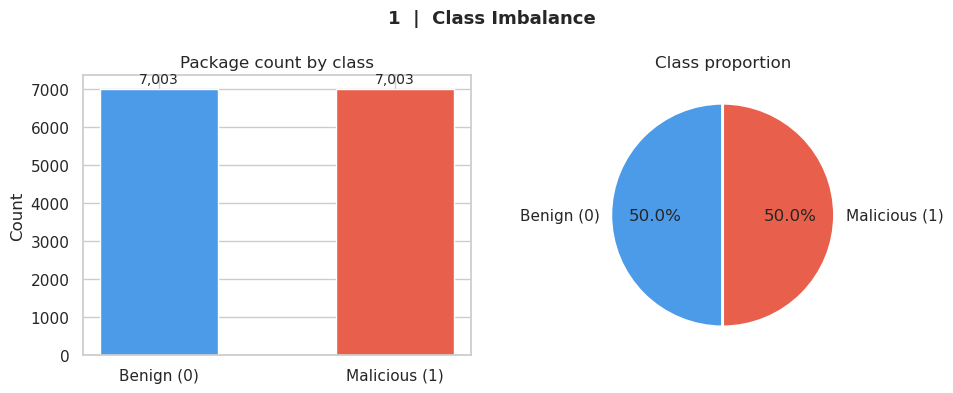

No missing values — skipping missing-value chart.


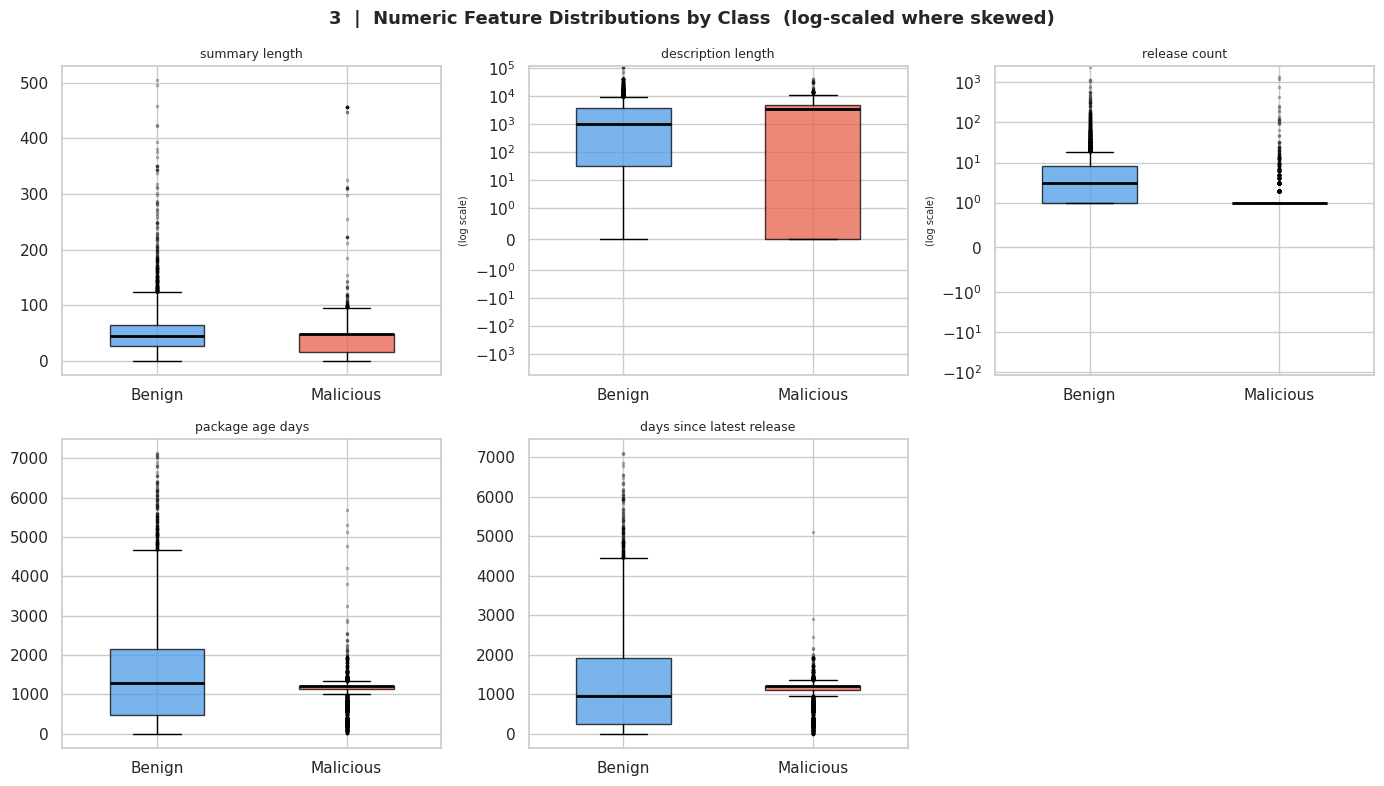

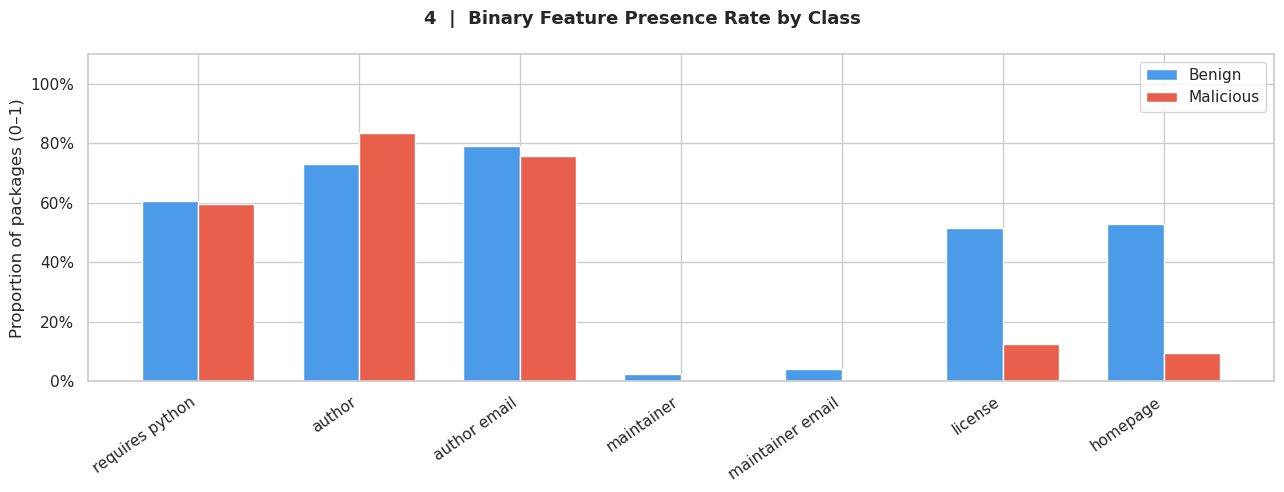

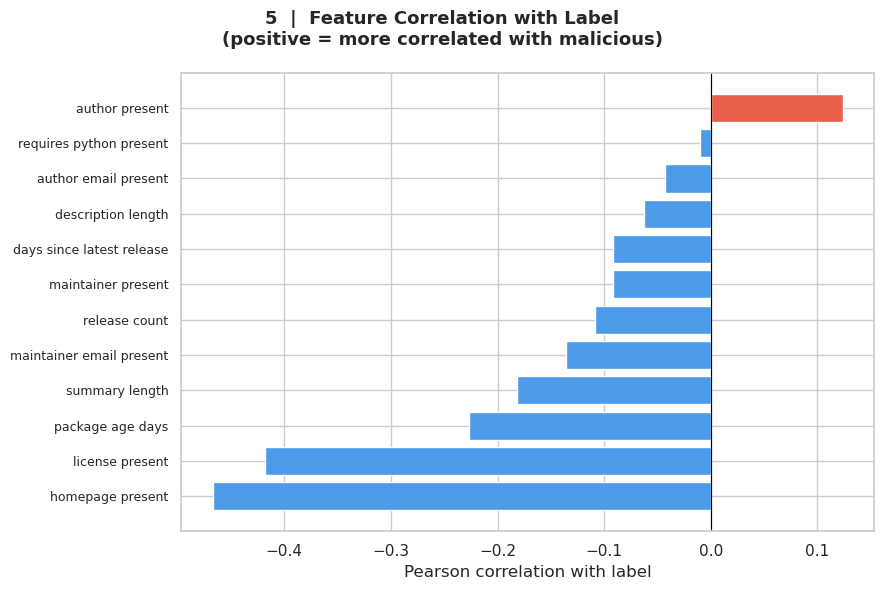

Charts saved to supply_chain_risk_dataset/processed


In [14]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", palette="muted")
except ImportError:
    sns = None
    print("seaborn not installed — falling back to plain matplotlib.")

_df = ml_df.copy()
_df["label"] = _df["label"].astype(int)
_df["label_name"] = _df["label"].map({0: "Benign", 1: "Malicious"})

COLORS = {0: "#4C9BE8", 1: "#E8604C"}
LABEL_COLORS = ["#4C9BE8", "#E8604C"]

numeric_feature_cols = [c for c in [
    "summary_length", "description_length", "release_count",
    "package_age_days", "days_since_latest_release",
    "dependency_count_from_requires_dist", "project_urls_count",
    "name_similarity_to_popular_package",
] if c in _df.columns]

binary_cols = [c for c in [
    "requires_python_present", "author_present", "author_email_present",
    "maintainer_present", "maintainer_email_present",
    "license_present", "homepage_present", "repo_url_present", "typosquatting_risk",
] if c in _df.columns]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("1  |  Class Imbalance", fontsize=13, fontweight="bold")

counts = _df["label"].value_counts().sort_index()
_label_name_map = {0: "Benign (0)", 1: "Malicious (1)"}
_color_map = {0: "#4C9BE8", 1: "#E8604C"}
labels_txt = [_label_name_map[k] for k in counts.index]
pie_colors = [_color_map[k] for k in counts.index]

axes[0].bar(labels_txt, counts.values, color=pie_colors, edgecolor="white", width=0.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + max(counts.values) * 0.01, f"{v:,}", ha="center", va="bottom", fontsize=10)
axes[0].set_ylabel("Count")
axes[0].set_title("Package count by class")

axes[1].pie(
    counts.values,
    labels=labels_txt,
    colors=pie_colors,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
)
axes[1].set_title("Class proportion")

plt.tight_layout()
plt.savefig(str(PROCESSED_DIR / "eda_class_imbalance.png"), dpi=120, bbox_inches="tight")
plt.show()

missing_pct = (_df.isnull().sum() / len(_df) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

if missing_pct.empty:
    print("No missing values — skipping missing-value chart.")
else:
    fig, ax = plt.subplots(figsize=(10, 4))
    fig.suptitle("2  |  Missing Value Rate per Feature", fontsize=13, fontweight="bold")
    ax.barh(missing_pct.index[::-1], missing_pct.values[::-1], color="#9B59B6", edgecolor="white")
    ax.set_xlabel("Missing %")
    ax.xaxis.set_major_formatter(mticker.PercentFormatter())
    plt.tight_layout()
    plt.savefig(str(PROCESSED_DIR / "eda_missing_values.png"), dpi=120, bbox_inches="tight")
    plt.show()

n_cols = 3
n_rows = int(np.ceil(len(numeric_feature_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
fig.suptitle("3  |  Numeric Feature Distributions by Class  (log-scaled where skewed)", fontsize=13, fontweight="bold")
axes = axes.flatten()

for i, col in enumerate(numeric_feature_cols):
    ax = axes[i]
    groups = [
        _df.loc[_df["label"] == lbl, col].dropna().values
        for lbl in [0, 1]
    ]
    bp = ax.boxplot(
        groups,
        patch_artist=True,
        medianprops={"color": "black", "linewidth": 2},
        flierprops={"marker": ".", "markersize": 3, "alpha": 0.3},
        widths=0.5,
    )
    for patch, color in zip(bp["boxes"], LABEL_COLORS):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Benign", "Malicious"])
    ax.set_title(col.replace("_", " "), fontsize=9)
    # Apply log scale if range is large
    vals = _df[col].dropna()
    if vals.max() > 0 and vals.max() / max(vals.median(), 1) > 50:
        ax.set_yscale("symlog", linthresh=1)
        ax.set_ylabel("(log scale)", fontsize=7)

for j in range(len(numeric_feature_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(str(PROCESSED_DIR / "eda_numeric_distributions.png"), dpi=120, bbox_inches="tight")
plt.show()

flag_rates = _df.groupby("label")[binary_cols].mean().T.rename(
    columns={k: v for k, v in {0: "Benign", 1: "Malicious"}.items() if k in _df["label"].unique()}
)

x = np.arange(len(binary_cols))
width = 0.35
fig, ax = plt.subplots(figsize=(13, 5))
fig.suptitle("4  |  Binary Feature Presence Rate by Class", fontsize=13, fontweight="bold")

if "Benign" in flag_rates.columns:
    ax.bar(x - width / 2, flag_rates["Benign"].values, width, label="Benign", color=COLORS[0], edgecolor="white")
if "Malicious" in flag_rates.columns:
    ax.bar(x + width / 2, flag_rates["Malicious"].values, width, label="Malicious", color=COLORS[1], edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels([c.replace("_present", "").replace("_", " ") for c in binary_cols], rotation=35, ha="right")
ax.set_ylabel("Proportion of packages (0–1)")
ax.set_ylim(0, 1.1)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend()
plt.tight_layout()
plt.savefig(str(PROCESSED_DIR / "eda_binary_feature_rates.png"), dpi=120, bbox_inches="tight")
plt.show()

all_feat_cols = numeric_feature_cols + binary_cols
corr = (
    _df[all_feat_cols + ["label"]]
    .apply(lambda c: c.corr(_df["label"]) if c.name != "label" else None)
    .dropna()
    .sort_values()
)

colors_corr = [COLORS[1] if v > 0 else COLORS[0] for v in corr.values]
fig, ax = plt.subplots(figsize=(9, 6))
fig.suptitle("5  |  Feature Correlation with Label\n(positive = more correlated with malicious)", fontsize=13, fontweight="bold")
ax.barh(corr.index, corr.values, color=colors_corr, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Pearson correlation with label")
ax.set_yticklabels([c.replace("_", " ") for c in corr.index], fontsize=9)
plt.tight_layout()
plt.savefig(str(PROCESSED_DIR / "eda_feature_correlation.png"), dpi=120, bbox_inches="tight")
plt.show()

if "pypi_found" in _df.columns:
    found_rate = _df.groupby("label_name")["pypi_found"].mean()
    fig, ax = plt.subplots(figsize=(5, 4))
    fig.suptitle("6  |  PyPI Found Rate by Class", fontsize=13, fontweight="bold")
    ax.bar(found_rate.index, found_rate.values,
           color=[COLORS[0] if x == "Benign" else COLORS[1] for x in found_rate.index],
           edgecolor="white", width=0.4)
    ax.set_ylabel("Proportion found on PyPI")
    ax.set_ylim(0, 1.1)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    for i, (name, val) in enumerate(found_rate.items()):
        ax.text(i, val + 0.02, f"{val:.1%}", ha="center", fontsize=10)
    plt.tight_layout()
    plt.savefig(str(PROCESSED_DIR / "eda_pypi_found_rate.png"), dpi=120, bbox_inches="tight")
    plt.show()

print("Charts saved to", PROCESSED_DIR)


# Model Training

Trains three models (Logistic Regression, Random Forest, XGBoost) with a 70/15/15 stratified split. Leaky features (`pypi_found`, `download_count_30d`, similarity scores) are excluded. Residual NaN handled by median imputation.


Model features (35):
  summary_length
  description_length
  requires_python_present
  author_present
  author_email_present
  maintainer_present
  maintainer_email_present
  license_present
  homepage_present
  release_count
  package_age_days
  days_since_latest_release
  name_length
  name_entropy
  digit_count
  has_digits
  hyphen_count
  underscore_count
  dot_count
  starts_with_py
  ends_with_py
  all_lowercase
  has_special_chars
  summary_length_missing
  description_length_missing
  requires_python_present_missing
  author_present_missing
  author_email_present_missing
  maintainer_present_missing
  maintainer_email_present_missing
  license_present_missing
  homepage_present_missing
  release_count_missing
  package_age_days_missing
  days_since_latest_release_missing
All feature columns are numeric.
NaN count: 0 across all features

Dataset: 14,006 rows × 35 features
Label counts:
label
malicious    7003
benign       7003

Class imbalance ratio (benign:malicious): 1.0:1

S

ROC-AUC=0.8999  F1=0.8417

Training Random Forest... 

ROC-AUC=0.9764  F1=0.9237

Training XGBoost... 

ROC-AUC=0.9772  F1=0.9289

MODEL COMPARISON — Validation Set
                     ROC-AUC  PR-AUC      F1  Precision  Recall
XGBoost               0.9772  0.9778  0.9289     0.9312  0.9267
Random Forest         0.9764  0.9758  0.9237     0.9322  0.9153
Logistic Regression   0.8999  0.8576  0.8417     0.8197  0.8649

BEST MODEL: XGBoost  (held-out test set)
              precision    recall  f1-score   support

      benign     0.9163    0.9477    0.9317      1051
   malicious     0.9458    0.9133    0.9293      1050

    accuracy                         0.9305      2101
   macro avg     0.9310    0.9305    0.9305      2101
weighted avg     0.9310    0.9305    0.9305      2101

ROC-AUC : 0.9814
PR-AUC  : 0.9790


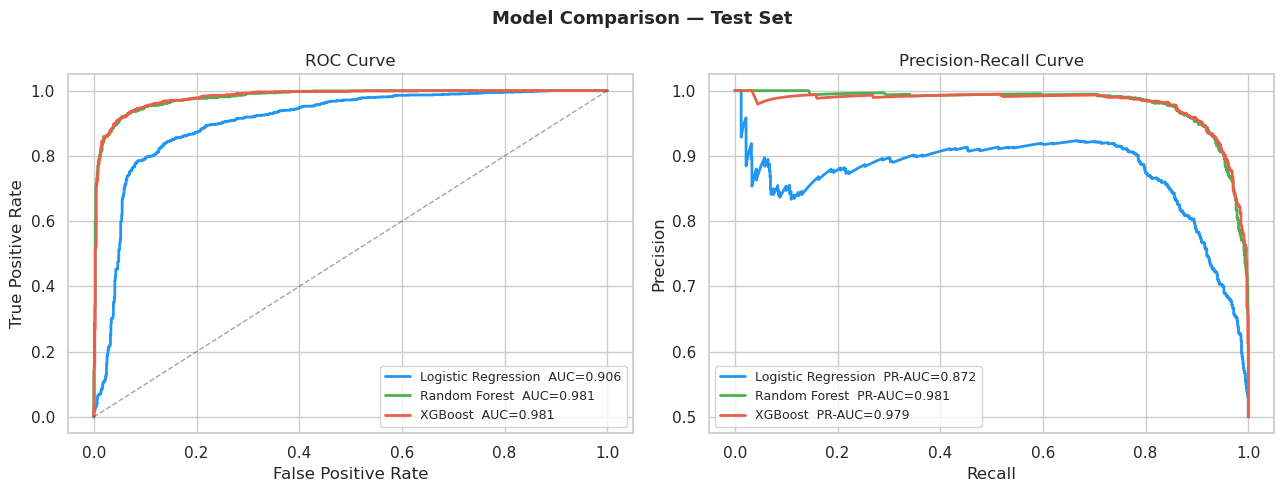

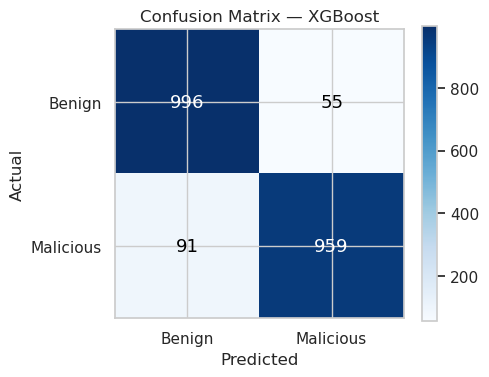

Saved 3 rows -> supply_chain_risk_dataset/processed/model_comparison_results.csv

Saved: best_model_pipeline.pkl  (model=XGBoost)
Saved: feature_cols.pkl  (35 features)

GENERALIZATION TESTS

1. Train/Test AUC gap : 0.0080  (Healthy (< 0.05))
   Train AUC = 0.9894  |  Test AUC = 0.9814



2. 5-fold CV AUC : 0.9807 +/- 0.0032
   Per-fold      : [np.float64(0.9803), np.float64(0.9822), np.float64(0.9838), np.float64(0.9824), np.float64(0.9747)]
   Consistent    : YES



3. Permutation test : p-value = 0.0000  (Significant)
   Null AUC mean   : 0.4981  |  Real AUC = 0.9814
   Result          : Model NOT memorizing -- result is real


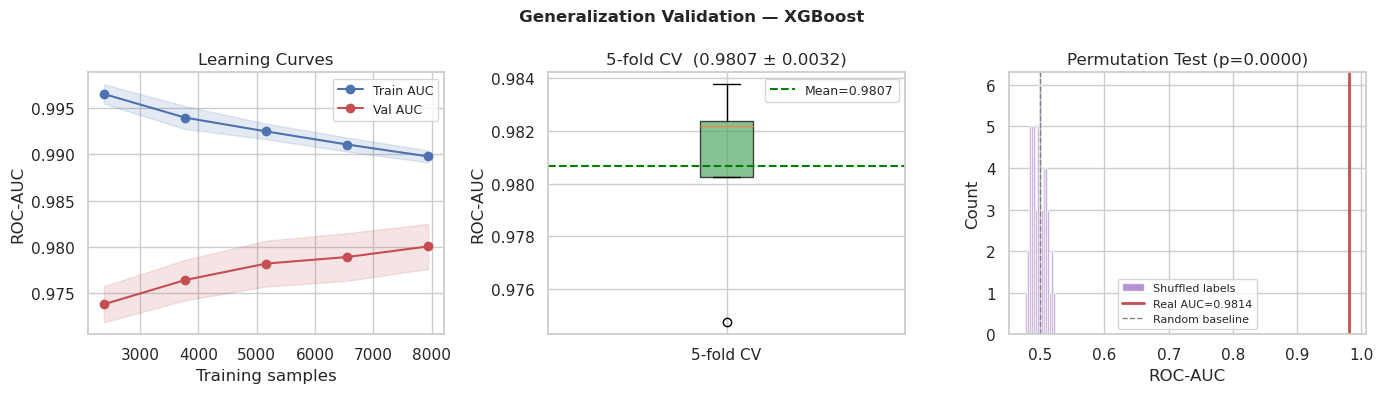


Generalization plot saved to supply_chain_risk_dataset/processed/generalization_tests.png


In [15]:
import joblib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
)

# Leaky features excluded from training

LEAKY_FEATURES = {
    "download_count_30d",
    "name_similarity_to_popular_package",
    "typosquatting_risk",
    "pypi_found",
}

NON_FEATURES = {
    "package_name", "normalized_name", "ecosystem",
    "label", "label_source", "latest_version", "closest_popular_package",
}

# Convert to numeric BEFORE defining feature_cols
for col in ml_df.columns:
    if col not in NON_FEATURES and col not in LEAKY_FEATURES:
        ml_df[col] = pd.to_numeric(ml_df[col], errors="coerce")

feature_cols = [
    c for c in ml_df.columns
    if c not in NON_FEATURES
    and c not in LEAKY_FEATURES
    and ml_df[c].dtype in ["int64", "float64", "int32", "float32"]
]
print(f"Model features ({len(feature_cols)}):\n  " + "\n  ".join(feature_cols))

if len(feature_cols) == 0:
    raise ValueError("No numeric feature columns found. Re-run Parts D–F to rebuild ml_df.")

ml_df[feature_cols] = ml_df[feature_cols].astype("float64")

_bad = ml_df[feature_cols].select_dtypes(include=["object"]).columns.tolist()
if _bad:
    raise ValueError(f"Non-numeric feature columns still present: {_bad}")
print("All feature columns are numeric.")

# NaN summary per feature
_nan_pct = (ml_df[feature_cols].isna().mean() * 100).round(1)
_nan_pct = _nan_pct[_nan_pct > 0]
if not _nan_pct.empty:
    print(f"\nNaN % per feature (will be median-imputed):\n{_nan_pct.to_string()}")
else:
    print("NaN count: 0 across all features")

ml_df = ml_df.dropna(subset=["label"]).copy()
X = ml_df[feature_cols]
y = ml_df["label"].astype(int)

print(f"\nDataset: {X.shape[0]:,} rows × {X.shape[1]} features")
_lc = y.value_counts().rename({0: "benign", 1: "malicious"})
print(f"Label counts:\n{_lc.to_string()}")

_ratio = _lc.get("benign", 0) / max(_lc.get("malicious", 1), 1)
print(f"\nClass imbalance ratio (benign:malicious): {_ratio:.1f}:1")

if y.nunique() < 2:
    raise ValueError(f"Only one class found. Distribution: {y.value_counts().to_dict()}")

X_tmp, X_test, y_tmp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp, test_size=round(0.15 / 0.85, 4), random_state=42, stratify=y_tmp
)
print(f"\nSplit → train: {len(y_train):,}  val: {len(y_val):,}  test: {len(y_test):,}")

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = max(1, round(neg / max(pos, 1)))
print(f"Class weight (benign:malicious) = {spw}:1")

pipelines = {
    "Logistic Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
        ("model",   LogisticRegression(
            max_iter=1000, class_weight="balanced", C=0.1, random_state=42,
        )),
    ]),
    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model",   RandomForestClassifier(
            n_estimators=300, max_depth=10,
            class_weight="balanced", random_state=42, n_jobs=-1,
        )),
    ]),
    "XGBoost": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model",   XGBClassifier(
            n_estimators=300, max_depth=4, learning_rate=0.05,
            subsample=0.9, colsample_bytree=0.9,
            eval_metric="logloss", random_state=42,
            scale_pos_weight=spw,
        )),
    ]),
}

val_results = {}
trained_pipelines = {}

for name, pipe in pipelines.items():
    print(f"\nTraining {name}...", end=" ")
    pipe.fit(X_train, y_train)
    trained_pipelines[name] = pipe

    pred_v = pipe.predict(X_val)
    prob_v = pipe.predict_proba(X_val)[:, 1]
    cr = classification_report(y_val, pred_v, output_dict=True, zero_division=0)

    val_results[name] = {
        "ROC-AUC":   round(roc_auc_score(y_val, prob_v), 4),
        "PR-AUC":    round(average_precision_score(y_val, prob_v), 4),
        "F1":        round(cr["1"]["f1-score"], 4),
        "Precision": round(cr["1"]["precision"], 4),
        "Recall":    round(cr["1"]["recall"], 4),
    }
    print(f"ROC-AUC={val_results[name]['ROC-AUC']:.4f}  F1={val_results[name]['F1']:.4f}")

val_df = pd.DataFrame(val_results).T.sort_values("ROC-AUC", ascending=False)
print("\n" + "=" * 60)
print("MODEL COMPARISON — Validation Set")
print("=" * 60)
print(val_df.to_string())

best_name = val_df["ROC-AUC"].idxmax()
best_pipe  = trained_pipelines[best_name]
pred_t = best_pipe.predict(X_test)
prob_t = best_pipe.predict_proba(X_test)[:, 1]

print(f"\n{'='*60}")
print(f"BEST MODEL: {best_name}  (held-out test set)")
print("=" * 60)
print(classification_report(y_test, pred_t,
      target_names=["benign", "malicious"], digits=4, zero_division=0))
print(f"ROC-AUC : {roc_auc_score(y_test, prob_t):.4f}")
print(f"PR-AUC  : {average_precision_score(y_test, prob_t):.4f}")

CURVE_COLORS = {
    "Logistic Regression": "#2196F3",
    "Random Forest":       "#4CAF50",
    "XGBoost":             "#E8604C",
}
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Model Comparison — Test Set", fontsize=13, fontweight="bold")

for name, pipe in trained_pipelines.items():
    p = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, p)
    axes[0].plot(fpr, tpr, lw=2, color=CURVE_COLORS[name],
                 label=f"{name}  AUC={roc_auc_score(y_test, p):.3f}")
    prec, rec, _ = precision_recall_curve(y_test, p)
    axes[1].plot(rec, prec, lw=2, color=CURVE_COLORS[name],
                 label=f"{name}  PR-AUC={average_precision_score(y_test, p):.3f}")

axes[0].plot([0, 1], [0, 1], "k--", lw=1, alpha=0.4)
axes[0].set(xlabel="False Positive Rate", ylabel="True Positive Rate", title="ROC Curve")
axes[0].legend(fontsize=9)
axes[1].set(xlabel="Recall", ylabel="Precision", title="Precision-Recall Curve")
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.savefig(str(PROCESSED_DIR / "model_comparison_curves.png"), dpi=120, bbox_inches="tight")
plt.show()

cm = confusion_matrix(y_test, pred_t)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["Benign", "Malicious"])
ax.set_yticklabels(["Benign", "Malicious"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix — {best_name}")
plt.colorbar(im, ax=ax)
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i,j]:,}", ha="center", va="center", fontsize=13,
                color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.tight_layout()
plt.savefig(str(PROCESSED_DIR / "confusion_matrix.png"), dpi=120, bbox_inches="tight")
plt.show()

joblib.dump(best_pipe,    str(PROCESSED_DIR / "best_model_pipeline.pkl"))
joblib.dump(feature_cols, str(PROCESSED_DIR / "feature_cols.pkl"))
save_csv(val_df.reset_index().rename(columns={"index": "model"}),
         "model_comparison_results.csv")
print(f"\nSaved: best_model_pipeline.pkl  (model={best_name})")
print(f"Saved: feature_cols.pkl  ({len(feature_cols)} features)")
# ── GENERALIZATION TESTS ──────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("GENERALIZATION TESTS")
print("=" * 60)

import numpy as _np
from sklearn.base import clone as _clone
from sklearn.model_selection import StratifiedKFold, learning_curve
from sklearn.metrics import roc_auc_score as _roc

# 1. Train / Test AUC gap
_tr_auc = _roc(y_train, best_pipe.predict_proba(X_train)[:, 1])
_te_auc = _roc(y_test,  best_pipe.predict_proba(X_test)[:,  1])
_gap    = _tr_auc - _te_auc
print(f"\n1. Train/Test AUC gap : {_gap:.4f}  ({'Healthy (< 0.05)' if _gap < 0.05 else 'WARNING: possible overfit'})")
print(f"   Train AUC = {_tr_auc:.4f}  |  Test AUC = {_te_auc:.4f}")

# 2. 5-fold cross-validation (train + val combined)
_X_cv = _np.vstack([X_train, X_val])
_y_cv = _np.concatenate([y_train, y_val])
_cv   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
_cv_scores = []
for _tr_idx, _va_idx in _cv.split(_X_cv, _y_cv):
    _fold_pipe = _clone(best_pipe)
    _fold_pipe.fit(_X_cv[_tr_idx], _y_cv[_tr_idx])
    _cv_scores.append(_roc(_y_cv[_va_idx], _fold_pipe.predict_proba(_X_cv[_va_idx])[:, 1]))
_cv_scores = _np.array(_cv_scores)
print(f"\n2. 5-fold CV AUC : {_cv_scores.mean():.4f} +/- {_cv_scores.std():.4f}")
print(f"   Per-fold      : {[round(s,4) for s in _cv_scores]}")
print(f"   Consistent    : {'YES' if _cv_scores.std() < 0.02 else 'NO -- high variance'}")

# 3. Permutation test (50 shuffles)
_rng = _np.random.default_rng(42)
_null_aucs = [_roc(_rng.permutation(y_test), best_pipe.predict_proba(X_test)[:, 1])
              for _ in range(50)]
_null_aucs = _np.array(_null_aucs)
_p_val = (_null_aucs >= _te_auc).mean()
print(f"\n3. Permutation test : p-value = {_p_val:.4f}  ({'Significant' if _p_val < 0.05 else 'NOT significant'})")
print(f"   Null AUC mean   : {_null_aucs.mean():.4f}  |  Real AUC = {_te_auc:.4f}")
print(f"   Result          : {'Model NOT memorizing -- result is real' if _p_val < 0.05 else 'WARNING: indistinguishable from chance'}")

# 4. Learning curves
_lc_sizes, _lc_tr, _lc_va = learning_curve(
    _clone(best_pipe), _X_cv, _y_cv,
    cv=3, scoring="roc_auc",
    train_sizes=_np.linspace(0.3, 1.0, 5),
    n_jobs=-1
)

# ── Generalization plots ──────────────────────────────────────────────────────
fig_g, axes_g = plt.subplots(1, 3, figsize=(14, 4))
fig_g.suptitle(f"Generalization Validation — {best_name}", fontsize=12, fontweight="bold")

# Plot 1: Learning curves
axes_g[0].plot(_lc_sizes, _lc_tr.mean(1), "o-", color="#4C72B0", label="Train AUC")
axes_g[0].fill_between(_lc_sizes, _lc_tr.mean(1)-_lc_tr.std(1),
                       _lc_tr.mean(1)+_lc_tr.std(1), alpha=0.15, color="#4C72B0")
axes_g[0].plot(_lc_sizes, _lc_va.mean(1), "o-", color="#C44E52", label="Val AUC")
axes_g[0].fill_between(_lc_sizes, _lc_va.mean(1)-_lc_va.std(1),
                       _lc_va.mean(1)+_lc_va.std(1), alpha=0.15, color="#C44E52")
axes_g[0].set(xlabel="Training samples", ylabel="ROC-AUC", title="Learning Curves")
axes_g[0].legend(fontsize=9)

# Plot 2: 5-fold CV box
axes_g[1].boxplot(_cv_scores, vert=True, patch_artist=True,
                  boxprops=dict(facecolor="#55A868", alpha=0.7))
axes_g[1].axhline(_cv_scores.mean(), color="green", linestyle="--",
                  label=f"Mean={_cv_scores.mean():.4f}")
axes_g[1].set(title=f"5-fold CV  ({_cv_scores.mean():.4f} ± {_cv_scores.std():.4f})",
              ylabel="ROC-AUC", xticklabels=["5-fold CV"])
axes_g[1].legend(fontsize=9)

# Plot 3: Permutation test histogram
axes_g[2].hist(_null_aucs, bins=15, color="#9467BD", alpha=0.7, label="Shuffled labels")
axes_g[2].axvline(_te_auc, color="#C44E52", linewidth=2, label=f"Real AUC={_te_auc:.4f}")
axes_g[2].axvline(0.5, color="gray", linewidth=1, linestyle="--", label="Random baseline")
axes_g[2].set(xlabel="ROC-AUC", ylabel="Count",
              title=f"Permutation Test (p={_p_val:.4f})")
axes_g[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(str(PROCESSED_DIR / "generalization_tests.png"), dpi=120, bbox_inches="tight")
plt.show()
print("\n" + "=" * 60)
print(f"Generalization plot saved to {PROCESSED_DIR / 'generalization_tests.png'}")
print("=" * 60)


# SHAP Explainability


SHAP input: (2101, 35)  (model n_features_in_: 35)


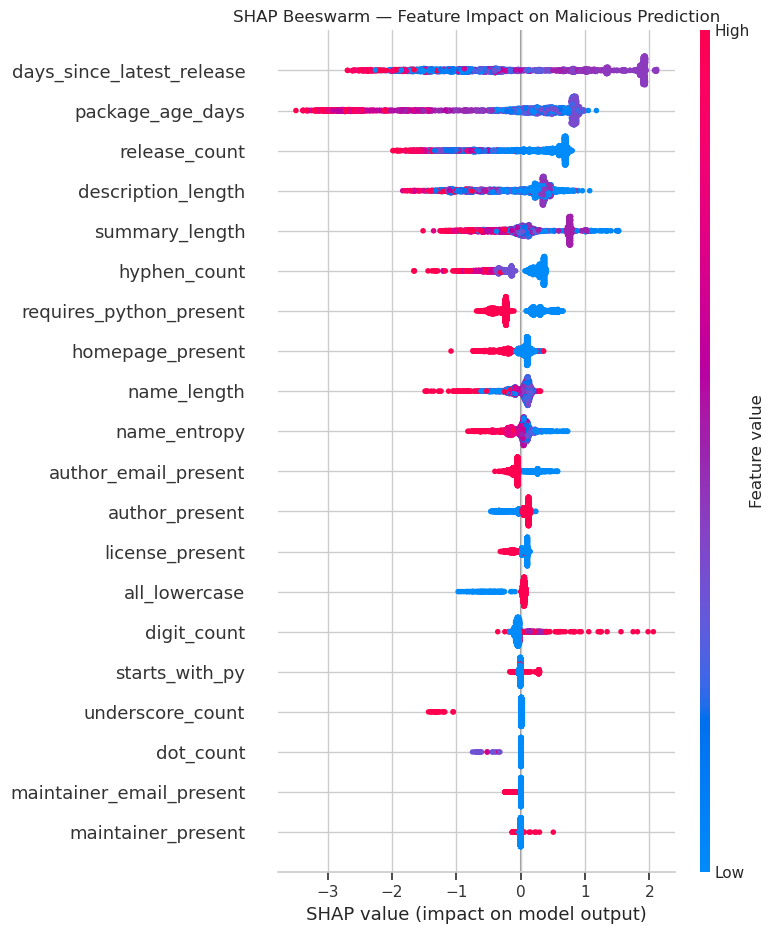

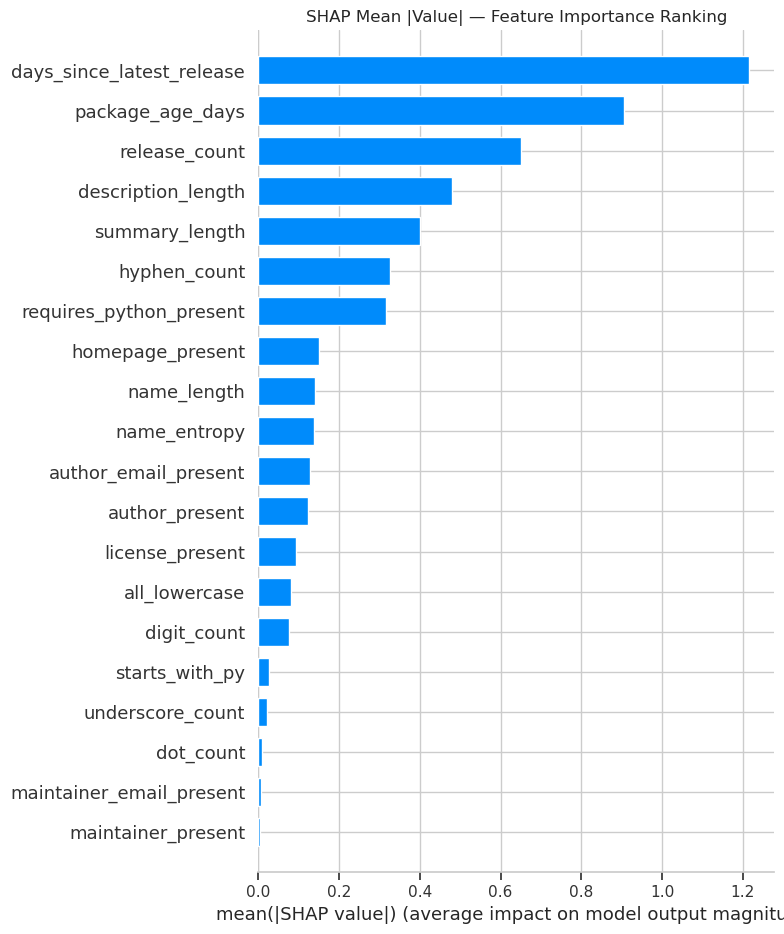

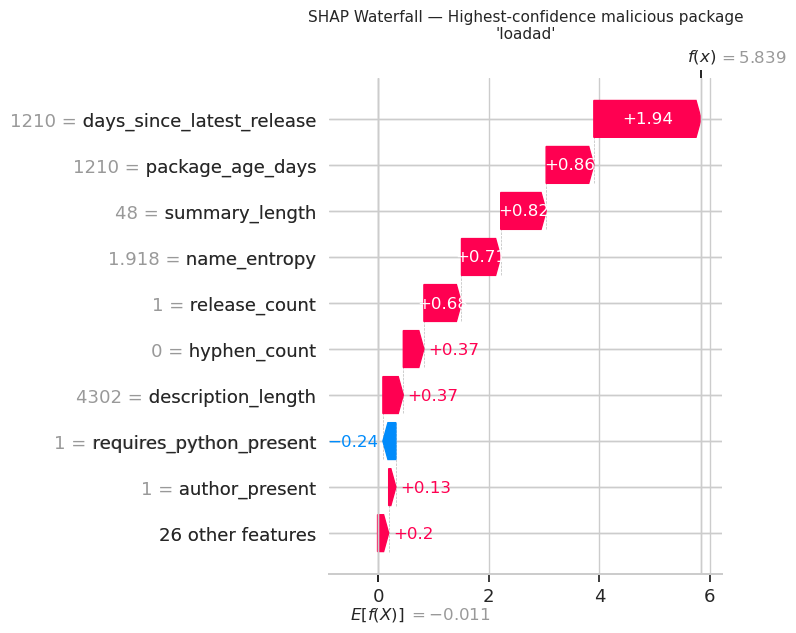

Waterfall shown for package: 'loadad'

SHAP plots saved to supply_chain_risk_dataset/processed


In [16]:
try:
    import shap
    shap.initjs()

    # Use the XGBoost model for SHAP (tree explainer is exact, not approximate)
    xgb_pipe  = trained_pipelines["XGBoost"]
    xgb_model = xgb_pipe.named_steps["model"]

    # SimpleImputer drops all-NaN columns (keep_empty_features=False, sklearn ≥ 1.2).
    # The 3 columns that are 100 % NaN in training are dropped, so XGBoost was
    # fitted on 23 features, but raw X_test has 26 → dimension mismatch.
    # Solution: run X_test through the imputer before handing to SHAP.
    imputer = xgb_pipe.named_steps["imputer"]
    X_shap_arr = imputer.transform(X_test)

    # Recover feature names surviving after imputation
    try:
        shap_feature_names = list(imputer.get_feature_names_out(feature_cols))
    except Exception:
        shap_feature_names = feature_cols[:X_shap_arr.shape[1]]

    X_shap = pd.DataFrame(X_shap_arr, columns=shap_feature_names, index=X_test.index)
    print(f"SHAP input: {X_shap.shape}  (model n_features_in_: {xgb_model.n_features_in_})")

    explainer   = shap.TreeExplainer(xgb_model)
    shap_values = explainer.shap_values(X_shap)

    plt.figure(figsize=(10, 7))
    shap.summary_plot(
        shap_values, X_shap,
        feature_names=shap_feature_names,
        show=False,
    )
    plt.title("SHAP Beeswarm — Feature Impact on Malicious Prediction", fontsize=12)
    plt.tight_layout()
    plt.savefig(str(PROCESSED_DIR / "shap_beeswarm.png"), dpi=120, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(9, 6))
    shap.summary_plot(
        shap_values, X_shap,
        feature_names=shap_feature_names,
        plot_type="bar",
        show=False,
    )
    plt.title("SHAP Mean |Value| — Feature Importance Ranking", fontsize=12)
    plt.tight_layout()
    plt.savefig(str(PROCESSED_DIR / "shap_bar_importance.png"), dpi=120, bbox_inches="tight")
    plt.show()

    mal_idx_arr = np.where(y_test.values == 1)[0]
    if len(mal_idx_arr) > 0:
        # Pick the test sample the model is most confident is malicious
        highest_risk_pos = mal_idx_arr[prob_t[mal_idx_arr].argmax()]
        pkg_name = ml_df.iloc[X_test.index[highest_risk_pos]]["package_name"]

        shap.waterfall_plot(
            shap.Explanation(
                values       = shap_values[highest_risk_pos],
                base_values  = explainer.expected_value,
                data         = X_shap.iloc[highest_risk_pos].values,
                feature_names= shap_feature_names,
            ),
            show=False,
        )
        plt.title(
            f"SHAP Waterfall — Highest-confidence malicious package\n'{pkg_name}'",
            fontsize=11,
        )
        plt.tight_layout()
        plt.savefig(str(PROCESSED_DIR / "shap_waterfall_example.png"), dpi=120, bbox_inches="tight")
        plt.show()
        print(f"Waterfall shown for package: '{pkg_name}'")

    print("\nSHAP plots saved to", PROCESSED_DIR)

except ImportError:
    print("shap not installed. Run:  pip install shap  then re-run this cell.")
except Exception as e:
    print(f"SHAP error: {e}")
    raise


# SageMaker Deployment


In [17]:
# Package model.tar.gz and deploy SageMaker endpoint
# SageMaker SDK V3-compatible version
# This version avoids old V2 imports:
#   - no sagemaker.sklearn.model.SKLearnModel
#   - no sagemaker.get_execution_role()
#   - no sagemaker.serializers / deserializers
#
# It uses:
#   - boto3 create_model / create_endpoint_config / create_endpoint
#   - SageMaker V3 image_uris.retrieve(...)
#   - SageMaker Runtime invoke_endpoint(...)

import os
import tarfile
import json
import shutil
import time
from pathlib import Path

required_artifacts = [
    PROCESSED_DIR / "best_model_pipeline.pkl",
    PROCESSED_DIR / "feature_cols.pkl",
]

missing = [str(p) for p in required_artifacts if not p.exists()]
if missing:
    raise FileNotFoundError(
        f"Missing model artifacts from Part G: {missing}. Run model training first."
    )

# SageMaker sklearn container calls model_fn / input_fn / predict_fn / output_fn.
INFERENCE_SCRIPT = """\
import json
import joblib
import os
import numpy as np
import pandas as pd


def model_fn(model_dir):
    pipeline  = joblib.load(os.path.join(model_dir, "best_model_pipeline.pkl"))
    feat_cols = joblib.load(os.path.join(model_dir, "feature_cols.pkl"))
    return {"pipeline": pipeline, "feature_cols": feat_cols}


def input_fn(request_body, content_type="application/json"):
    if content_type == "application/json":
        data = json.loads(request_body)
        return pd.DataFrame(data if isinstance(data, list) else [data])
    raise ValueError(f"Unsupported content type: {content_type}")


def predict_fn(input_data, model):
    pipeline  = model["pipeline"]
    feat_cols = model["feature_cols"]

    X = input_data.reindex(columns=feat_cols)

    proba  = pipeline.predict_proba(X)[:, 1]
    labels = pipeline.predict(X)

    return pd.DataFrame({
        "malicious_probability": proba.astype(float),
        "predicted_label": labels.astype(int),
    })


def output_fn(prediction, accept="application/json"):
    return prediction.to_json(orient="records"), "application/json"
"""

DEPLOY_DIR.mkdir(parents=True, exist_ok=True)

(DEPLOY_DIR / "inference.py").write_text(INFERENCE_SCRIPT)

# Critical fix:
# If the selected model is XGBoost, the sklearn serving container needs xgboost
# available at inference time.
try:
    import xgboost
    xgb_req = f"xgboost=={xgboost.__version__}"
except Exception:
    xgb_req = "xgboost"

(DEPLOY_DIR / "requirements.txt").write_text(
    "\n".join([
        xgb_req,
        "pandas",
        "numpy",
        "joblib",
    ]) + "\n"
)

shutil.copy(
    str(PROCESSED_DIR / "best_model_pipeline.pkl"),
    str(DEPLOY_DIR / "best_model_pipeline.pkl"),
)

shutil.copy(
    str(PROCESSED_DIR / "feature_cols.pkl"),
    str(DEPLOY_DIR / "feature_cols.pkl"),
)

model_tar_path = DEPLOY_DIR / "model.tar.gz"

with tarfile.open(model_tar_path, "w:gz") as tar:
    tar.add(str(DEPLOY_DIR / "inference.py"),            arcname="code/inference.py")
    tar.add(str(DEPLOY_DIR / "requirements.txt"),        arcname="code/requirements.txt")
    tar.add(str(DEPLOY_DIR / "best_model_pipeline.pkl"), arcname="best_model_pipeline.pkl")
    tar.add(str(DEPLOY_DIR / "feature_cols.pkl"),        arcname="feature_cols.pkl")

print("model.tar.gz created — contents:")

with tarfile.open(model_tar_path, "r:gz") as tar:
    for m in tar.getmembers():
        print(f"  {m.name}  ({m.size:,} bytes)")

try:
    import boto3
    from botocore.exceptions import ClientError
    from sagemaker.core.helper.session_helper import get_execution_role
    from sagemaker.core import image_uris

    boto_session = boto3.Session()
    region = (
        boto_session.region_name
        or os.environ.get("AWS_REGION")
        or os.environ.get("AWS_DEFAULT_REGION")
    )

    if not region:
        raise RuntimeError(
            "Could not determine AWS region. Run inside SageMaker Studio or configure AWS_DEFAULT_REGION."
        )

    sm = boto_session.client("sagemaker", region_name=region)
    s3 = boto_session.client("s3", region_name=region)
    sts = boto_session.client("sts", region_name=region)
    runtime = boto_session.client("sagemaker-runtime", region_name=region)

    account_id = sts.get_caller_identity()["Account"]

    bucket = None

    if "S3_BUCKET" in globals() and S3_BUCKET:
        bucket = S3_BUCKET
    elif "_bucket" in globals() and _bucket:
        bucket = _bucket
    else:
        bucket = f"sagemaker-{region}-{account_id}"

    role = get_execution_role()

    # Make sure model prefix is safe
    _model_prefix = S3_MODEL_PREFIX.strip("/") if "S3_MODEL_PREFIX" in globals() else "supply-chain-risk/models"
    _model_key = f"{_model_prefix}/model.tar.gz"

    print(f"\nUploading model artifact to S3...")
    print(f"  Bucket : {bucket}")
    print(f"  Key    : {_model_key}")

    s3.upload_file(
        Filename=str(model_tar_path),
        Bucket=bucket,
        Key=_model_key,
    )

    s3_model_uri = f"s3://{bucket}/{_model_key}"
    print(f"Model uploaded to: {s3_model_uri}")

    sklearn_image = image_uris.retrieve(
        framework="sklearn",
        region=region,
        version=SKLEARN_VERSION,
        py_version="py3",
        instance_type=INSTANCE_TYPE,
    )

    print(f"\nUsing sklearn image:")
    print(f"  {sklearn_image}")

    # Use names based on the endpoint name so cleanup is easy later.
    MODEL_NAME = f"{ENDPOINT_NAME}-model"
    ENDPOINT_CONFIG_NAME = f"{ENDPOINT_NAME}-config"

    print(f"\nCreating SageMaker model: {MODEL_NAME}")

    try:
        sm.create_model(
            ModelName=MODEL_NAME,
            ExecutionRoleArn=role,
            PrimaryContainer={
                "Image": sklearn_image,
                "ModelDataUrl": s3_model_uri,
                "Environment": {
                    # These tell the sklearn serving container to run code/inference.py
                    "SAGEMAKER_PROGRAM": "inference.py",
                    "SAGEMAKER_SUBMIT_DIRECTORY": "/opt/ml/model/code",
                    "SAGEMAKER_CONTAINER_LOG_LEVEL": "20",
                    "SAGEMAKER_REGION": region,
                },
            },
        )
        print(f"  ✓ Created model: {MODEL_NAME}")

    except ClientError as e:
        if "already exists" in str(e).lower():
            print(f"  • Model already exists: {MODEL_NAME}")
        else:
            raise

    print(f"\nCreating endpoint config: {ENDPOINT_CONFIG_NAME}")

    try:
        sm.create_endpoint_config(
            EndpointConfigName=ENDPOINT_CONFIG_NAME,
            ProductionVariants=[
                {
                    "VariantName": "AllTraffic",
                    "ModelName": MODEL_NAME,
                    "InitialInstanceCount": 1,
                    "InstanceType": INSTANCE_TYPE,
                    "InitialVariantWeight": 1.0,
                }
            ],
        )
        print(f"  ✓ Created endpoint config: {ENDPOINT_CONFIG_NAME}")

    except ClientError as e:
        if "already exists" in str(e).lower():
            print(f"  • Endpoint config already exists: {ENDPOINT_CONFIG_NAME}")
        else:
            raise

    print(f"\nDeploying endpoint '{ENDPOINT_NAME}' on {INSTANCE_TYPE}...")

    endpoint_exists = False

    try:
        sm.describe_endpoint(EndpointName=ENDPOINT_NAME)
        endpoint_exists = True
    except ClientError as e:
        if "Could not find endpoint" in str(e) or "ValidationException" in str(e):
            endpoint_exists = False
        else:
            raise

    if endpoint_exists:
        print(f"  • Endpoint already exists. Updating endpoint: {ENDPOINT_NAME}")
        sm.update_endpoint(
            EndpointName=ENDPOINT_NAME,
            EndpointConfigName=ENDPOINT_CONFIG_NAME,
        )
    else:
        sm.create_endpoint(
            EndpointName=ENDPOINT_NAME,
            EndpointConfigName=ENDPOINT_CONFIG_NAME,
        )

    print("Waiting for endpoint to reach InService status...")

    waiter = sm.get_waiter("endpoint_in_service")
    waiter.wait(
        EndpointName=ENDPOINT_NAME,
        WaiterConfig={
            "Delay": 30,
            "MaxAttempts": 40,
        },
    )

    print(f"Endpoint '{ENDPOINT_NAME}' is live.")

    sample = {
        col: float(X_test.iloc[0][col]) if pd.notna(X_test.iloc[0][col]) else None
        for col in feature_cols
    }

    payload = json.dumps([sample])

    invoke_resp = runtime.invoke_endpoint(
        EndpointName=ENDPOINT_NAME,
        ContentType="application/json",
        Accept="application/json",
        Body=payload,
    )

    response_body = invoke_resp["Body"].read().decode("utf-8")

    try:
        response = json.loads(response_body)
    except Exception:
        response = response_body

    print("\nSample prediction response:")
    print(json.dumps(response, indent=2) if isinstance(response, (dict, list)) else response)

    # Save a copy of the sample response for the report/video evidence.
    sample_output_path = PROCESSED_DIR / "sample_endpoint_prediction.json"

    with open(sample_output_path, "w") as f:
        json.dump(
            {
                "endpoint_name": ENDPOINT_NAME,
                "model_name": MODEL_NAME,
                "endpoint_config_name": ENDPOINT_CONFIG_NAME,
                "model_s3_uri": s3_model_uri,
                "response": response,
            },
            f,
            indent=2,
        )

    print(f"Saved: {sample_output_path}")

    if AUTO_DELETE_ENDPOINT_AFTER_TEST:
        print("\nAUTO_DELETE_ENDPOINT_AFTER_TEST=True, deleting endpoint now...")

        sm.delete_endpoint(EndpointName=ENDPOINT_NAME)

        try:
            deleted_waiter = sm.get_waiter("endpoint_deleted")
            deleted_waiter.wait(
                EndpointName=ENDPOINT_NAME,
                WaiterConfig={
                    "Delay": 20,
                    "MaxAttempts": 30,
                },
            )
        except Exception:
            pass

        try:
            sm.delete_endpoint_config(EndpointConfigName=ENDPOINT_CONFIG_NAME)
            print(f"Deleted endpoint config: {ENDPOINT_CONFIG_NAME}")
        except Exception as cleanup_exc:
            print(f"Endpoint config cleanup note: {cleanup_exc}")

        try:
            sm.delete_model(ModelName=MODEL_NAME)
            print(f"Deleted model: {MODEL_NAME}")
        except Exception as cleanup_exc:
            print(f"Model cleanup note: {cleanup_exc}")

        print("Endpoint deleted.")

    else:
        print("\nEndpoint left live for video/demo evidence.")
        print("When done, run the cleanup cell at the end or delete it in SageMaker Console.")

except ImportError as e:
    print(f"AWS/SageMaker import failed: {e}")
    print("This usually means the notebook has SDK V2 imports but the environment has SDK V3.")
    print(f"The SageMaker model artifact is ready locally at: {model_tar_path}")

except Exception as e:
    error_text = str(e).lower()

    if "execution role" in error_text or "credentials" in error_text or "unable to locate credentials" in error_text:
        print("AWS credentials not configured in this environment.")
        print("Run this cell inside SageMaker Studio or configure AWS credentials.")
        print(f"The packaged model is at: {model_tar_path}")

    else:
        print("SageMaker deployment failed. The local model artifact was still created.")
        print(f"Error: {e}")
        raise


model.tar.gz created — contents:
  code/inference.py  (1,094 bytes)
  code/requirements.txt  (35 bytes)
  best_model_pipeline.pkl  (464,619 bytes)
  feature_cols.pkl  (786 bytes)


sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml


sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml



Uploading model artifact to S3...
  Bucket : sagemaker-us-east-1-899625861818
  Key    : supply-chain-risk/models/model.tar.gz
Model uploaded to: s3://sagemaker-us-east-1-899625861818/supply-chain-risk/models/model.tar.gz

Using sklearn image:
  683313688378.dkr.ecr.us-east-1.amazonaws.com/sagemaker-scikit-learn:1.4-2-cpu-py3

Creating SageMaker model: supply-chain-risk-endpoint-20260621-020423-model


  ✓ Created model: supply-chain-risk-endpoint-20260621-020423-model

Creating endpoint config: supply-chain-risk-endpoint-20260621-020423-config


  ✓ Created endpoint config: supply-chain-risk-endpoint-20260621-020423-config

Deploying endpoint 'supply-chain-risk-endpoint-20260621-020423' on ml.m5.large...


Waiting for endpoint to reach InService status...


Endpoint 'supply-chain-risk-endpoint-20260621-020423' is live.

Sample prediction response:
[
  {
    "malicious_probability": 0.3744343519,
    "predicted_label": 0
  }
]
Saved: supply_chain_risk_dataset/processed/sample_endpoint_prediction.json

Endpoint left live for video/demo evidence.
When done, run the cleanup cell at the end or delete it in SageMaker Console.


# Model Monitoring & Drift Detection

Two-level monitoring strategy:

1. **Offline drift check** (this cell) — runs locally using KS-test and population stability index (PSI) to compare training feature distributions against any new batch of packages. Run this periodically (e.g., weekly) on newly scraped packages.

2. **SageMaker Model Monitor** (code stub below) — attach to the deployed endpoint to automatically capture traffic, compare distributions against a baseline, and alert on drift. Zero custom code required.


DRIFT REPORT — Training vs. Test distributions
(In production, replace X_test with a new batch of packages)


                          feature  ks_statistic  ks_p_value    psi  drifted_ks  drifted_psi
                 package_age_days        0.0295    0.096426 0.0083       False        False
                   summary_length        0.0269    0.161159 0.0042       False        False
        days_since_latest_release        0.0260    0.187717 0.0062       False        False
                     name_entropy        0.0225    0.341476 0.0061       False        False
               description_length        0.0198    0.502015 0.0053       False        False
                      name_length        0.0180    0.618649 0.0030       False        False
                   author_present        0.0122    0.954601 0.0009       False        False
          requires_python_present        0.0122    0.956582 0.0006       False        False
                    release_count        0.0114    0.976000 0.0006       False        False
                    all_lowercase        0.0107    0.987247 0.0018       False  

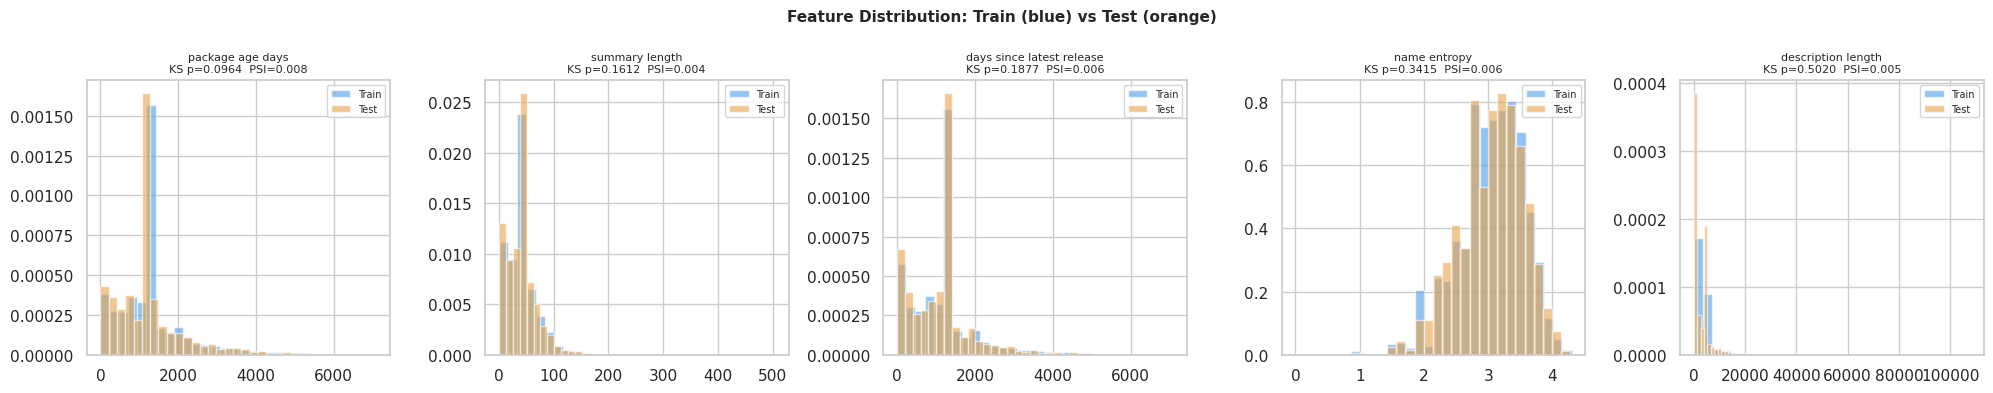

Saved 35 rows -> supply_chain_risk_dataset/processed/drift_report.csv

SageMaker Model Monitor — attach to live endpoint (run inside SageMaker Studio):

  from sagemaker.model_monitor import DefaultModelMonitor, CronExpressionGenerator

  monitor = DefaultModelMonitor(role=role, instance_count=1, instance_type="ml.m5.large")

  # Capture baseline statistics from training data
  monitor.suggest_baseline(
      baseline_dataset=f"s3://{bucket}/supply-chain-risk/baseline/train.csv",
      dataset_format=DatasetFormat.csv(header=True),
      output_s3_uri=f"s3://{bucket}/supply-chain-risk/baseline-results/",
  )

  # Schedule hourly drift checks
  monitor.create_monitoring_schedule(
      monitor_schedule_name="supply-chain-risk-monitor",
      endpoint_input=ENDPOINT_NAME,
      output_s3_uri=f"s3://{bucket}/supply-chain-risk/monitoring-reports/",
      statistics=monitor.baseline_statistics(),
      constraints=monitor.suggested_constraints(),
      schedule_cron_expression=CronExpressio

In [18]:
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Simulates what you would do when a new batch of packages arrives.
# Replace X_new_batch with your actual new data DataFrame.

def compute_psi(expected: np.ndarray, actual: np.ndarray, buckets: int = 10) -> float:
    """Population Stability Index.  PSI < 0.1 = stable, 0.1-0.2 = monitor, >0.2 = retrain."""
    def _pct(arr, edges):
        counts, _ = np.histogram(arr, bins=edges)
        pct = counts / len(arr)
        return np.where(pct == 0, 1e-6, pct)

    edges = np.percentile(expected, np.linspace(0, 100, buckets + 1))
    edges[0]  -= 1e-9
    edges[-1] += 1e-9
    e_pct = _pct(expected, edges)
    a_pct = _pct(actual,   edges)
    return float(np.sum((a_pct - e_pct) * np.log(a_pct / e_pct)))


def drift_report(X_train_ref: pd.DataFrame, X_new: pd.DataFrame,
                 feature_list: list, alpha: float = 0.05) -> pd.DataFrame:
    """KS-test + PSI for each feature. Returns DataFrame sorted by KS p-value (smallest = most drifted)."""
    rows = []
    for col in feature_list:
        ref = X_train_ref[col].dropna().values
        new = X_new[col].dropna().values
        if len(ref) < 5 or len(new) < 5:
            continue
        ks_stat, ks_p = stats.ks_2samp(ref, new)
        psi = compute_psi(ref, new)
        rows.append({
            "feature": col,
            "ks_statistic": round(ks_stat, 4),
            "ks_p_value":   round(ks_p,    6),
            "psi":          round(psi,      4),
            "drifted_ks":   ks_p < alpha,
            "drifted_psi":  psi > 0.2,
        })
    return pd.DataFrame(rows).sort_values("ks_p_value")


# Use test set as a proxy for "new production data"
print("=" * 60)
print("DRIFT REPORT — Training vs. Test distributions")
print("(In production, replace X_test with a new batch of packages)")
print("=" * 60)

drift_df = drift_report(X_train, X_test, feature_cols)
print(drift_df.to_string(index=False))

drifted = drift_df[drift_df["drifted_ks"] | drift_df["drifted_psi"]]
if drifted.empty:
    print("\nNo significant drift detected. Model is stable.")
else:
    print(f"\n⚠️  {len(drifted)} feature(s) show drift — consider retraining:")
    print(drifted[["feature", "ks_p_value", "psi"]].to_string(index=False))

top5 = drift_df.head(5)["feature"].tolist()
if top5:
    fig, axes = plt.subplots(1, len(top5), figsize=(4 * len(top5), 4))
    if len(top5) == 1:
        axes = [axes]
    fig.suptitle("Feature Distribution: Train (blue) vs Test (orange)", fontsize=11, fontweight="bold")
    for ax, col in zip(axes, top5):
        ax.hist(X_train[col].dropna(), bins=30, alpha=0.6, density=True,
                color="#4C9BE8", label="Train")
        ax.hist(X_test[col].dropna(),  bins=30, alpha=0.6, density=True,
                color="#E8A44C", label="Test")
        row = drift_df[drift_df["feature"] == col].iloc[0]
        ax.set_title(f"{col.replace('_', ' ')}\nKS p={row['ks_p_value']:.4f}  PSI={row['psi']:.3f}",
                     fontsize=8)
        ax.legend(fontsize=7)
    plt.tight_layout()
    plt.savefig(str(PROCESSED_DIR / "drift_top5_features.png"), dpi=120, bbox_inches="tight")
    plt.show()

save_csv(drift_df, "drift_report.csv")

print("""
SageMaker Model Monitor — attach to live endpoint (run inside SageMaker Studio):

  from sagemaker.model_monitor import DefaultModelMonitor, CronExpressionGenerator

  monitor = DefaultModelMonitor(role=role, instance_count=1, instance_type="ml.m5.large")

  # Capture baseline statistics from training data
  monitor.suggest_baseline(
      baseline_dataset=f"s3://{bucket}/supply-chain-risk/baseline/train.csv",
      dataset_format=DatasetFormat.csv(header=True),
      output_s3_uri=f"s3://{bucket}/supply-chain-risk/baseline-results/",
  )

  # Schedule hourly drift checks
  monitor.create_monitoring_schedule(
      monitor_schedule_name="supply-chain-risk-monitor",
      endpoint_input=ENDPOINT_NAME,
      output_s3_uri=f"s3://{bucket}/supply-chain-risk/monitoring-reports/",
      statistics=monitor.baseline_statistics(),
      constraints=monitor.suggested_constraints(),
      schedule_cron_expression=CronExpressionGenerator.hourly(),
  )
""")


# S3 Data Storage

All project data is stored in S3 to satisfy the rubric requirement *"Your data should be stored in S3 and documented in your GitHub repository"*.

**Upload layout:**
```
s3://<bucket>/supply-chain-risk/
  raw/                          ← DataDog manifest
  processed/                    ← CSVs, PNGs, model artifacts
```

Set `S3_BUCKET` in the SageMaker deployment cell (Part I) — it is reused here.


In [19]:
import os
import hashlib

# S3_BUCKET is set in the deployment cell above; reuse or override here.
try:
    _bucket = S3_BUCKET  # noqa: F821 — defined in deployment cell
except NameError:
    _bucket = ""         # will fall back to SageMaker default bucket

S3_DATA_PREFIX = "supply-chain-risk"

# Set True to force re-upload even when the file hasn't changed.
# When False (default), files are skipped if their MD5 matches the S3 ETag —
# the same behaviour as `aws s3 sync`.
FORCE_S3_UPLOAD = False


def _md5_of_file(path: Path) -> str:
    """Return hex MD5 of a local file."""
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            h.update(chunk)
    return h.hexdigest()


def _s3_etag(s3_client, bucket: str, key: str) -> str:
    """Return the ETag of an S3 object, or '' if it doesn't exist."""
    try:
        head = s3_client.head_object(Bucket=bucket, Key=key)
        # S3 ETags for small (non-multipart) uploads equal the MD5, without quotes
        return head["ETag"].strip('"')
    except s3_client.exceptions.ClientError:
        return ""


def _sync_dir_to_s3(local_dir: Path, s3_prefix: str,
                    s3_client, bucket: str, force: bool = False):
    """Upload files only when changed (ETag mismatch) or when force=True. Returns (uploaded, skipped) lists."""
    uploaded, skipped = [], []
    for local_path in sorted(local_dir.rglob("*")):
        if not local_path.is_file():
            continue
        rel = local_path.relative_to(local_dir)          # ← was local_dir.parent
        key = f"{s3_prefix}/{rel.as_posix()}"

        if not force:
            local_md5 = _md5_of_file(local_path)
            remote_etag = _s3_etag(s3_client, bucket, key)
            if local_md5 == remote_etag:
                skipped.append(key)
                continue

        s3_client.upload_file(str(local_path), bucket, key)
        uploaded.append(f"  UPLOADED  s3://{bucket}/{key}")

    return uploaded, skipped


try:
    import boto3
    from sagemaker.core.helper.session_helper import Session, get_execution_role

    sess   = Session()
    bucket = _bucket or sess.default_bucket()
    s3     = boto3.client("s3")

    print(f"S3 sync → s3://{bucket}/{S3_DATA_PREFIX}/  (FORCE={FORCE_S3_UPLOAD})\n")

    # Sync raw data (manifests)
    raw_up, raw_skip = _sync_dir_to_s3(
        RAW_DIR, f"{S3_DATA_PREFIX}/raw", s3, bucket, force=FORCE_S3_UPLOAD)
    print(f"raw/   — {len(raw_up)} uploaded, {len(raw_skip)} unchanged (skipped)")
    for line in raw_up:
        print(line)

    # Sync processed data (CSVs, PNGs, model artifacts)
    proc_up, proc_skip = _sync_dir_to_s3(
        PROCESSED_DIR, f"{S3_DATA_PREFIX}/processed", s3, bucket, force=FORCE_S3_UPLOAD)
    print(f"\nprocessed/ — {len(proc_up)} uploaded, {len(proc_skip)} unchanged (skipped)")
    for line in proc_up:
        print(line)

    # Sync SageMaker deployment artifacts, including model.tar.gz and inference.py
    if DEPLOY_DIR.exists():
        dep_up, dep_skip = _sync_dir_to_s3(
            DEPLOY_DIR, f"{S3_DATA_PREFIX}/deployment", s3, bucket, force=FORCE_S3_UPLOAD)
        print(f"\ndeployment/ — {len(dep_up)} uploaded, {len(dep_skip)} unchanged (skipped)")
        for line in dep_up:
            print(line)

    S3_PROCESSED_URI  = f"s3://{bucket}/{S3_DATA_PREFIX}/processed"
    S3_ML_DATASET_URI = f"{S3_PROCESSED_URI}/ml_ready_labeled_pypi_dataset.csv"

    print(f"\nML dataset S3 URI: {S3_ML_DATASET_URI}")

except ImportError:
    print("boto3 / sagemaker not installed — skipping S3 sync.")
    print("Run:  pip install boto3 sagemaker")
except Exception as e:
    if "credentials" in str(e).lower() or "execution role" in str(e).lower():
        print("AWS credentials not configured. Run inside SageMaker Studio")
        print("or configure ~/.aws/credentials with appropriate IAM permissions.")
    else:
        raise


S3 sync → s3://sagemaker-us-east-1-899625861818/supply-chain-risk/  (FORCE=False)

raw/   — 0 uploaded, 3 unchanged (skipped)



processed/ — 3 uploaded, 16 unchanged (skipped)
  UPLOADED  s3://sagemaker-us-east-1-899625861818/supply-chain-risk/processed/generalization_tests.png
  UPLOADED  s3://sagemaker-us-east-1-899625861818/supply-chain-risk/processed/sample_endpoint_prediction.json
  UPLOADED  s3://sagemaker-us-east-1-899625861818/supply-chain-risk/processed/shap_beeswarm.png

deployment/ — 1 uploaded, 4 unchanged (skipped)
  UPLOADED  s3://sagemaker-us-east-1-899625861818/supply-chain-risk/deployment/model.tar.gz

ML dataset S3 URI: s3://sagemaker-us-east-1-899625861818/supply-chain-risk/processed/ml_ready_labeled_pypi_dataset.csv


### SageMaker Processing Job *(Stage 3 · Production Feature Engineering)*

In the production AWS pipeline, the local feature-engineering cells (Parts D–F) are replaced by a **SageMaker Processing Job**.  The job runs `feature_engineering.py` on a managed `ml.m5.xlarge` instance, reads raw data from the S3 landing zone, and writes the ML-ready dataset back to S3 so the Feature Store (Part L) and Training Job (Part G) always pull from a versioned, auditable source.


In [20]:
# SageMaker Processing Job
# Notebook-safe version: does NOT require feature_engineering.py

from pathlib import Path

_proc_bucket = _bucket if _bucket else "<your-s3-bucket>"

_PROC_INPUT  = f"s3://{_proc_bucket}/{S3_DATA_PREFIX}/raw/"
_PROC_OUTPUT = f"s3://{_proc_bucket}/{S3_DATA_PREFIX}/processed/"

_SCRIPT_PATH = Path("feature_engineering.py")

if not _SCRIPT_PATH.exists():
    print(
        "Skipping actual SageMaker Processing Job submission.\n\n"
        "Reason:\n"
        "  This is a Jupyter notebook, and no separate feature_engineering.py script exists.\n"
        "  SageMaker Processing runs in a separate container, so it cannot directly execute notebook cells.\n\n"
        "Production job definition:\n"
        "  Processor : ScriptProcessor using sklearn image 1.2-1, ml.m5.xlarge\n"
        f"  Input     : {_PROC_INPUT}\n"
        f"  Output    : {_PROC_OUTPUT}\n"
        "  Script    : feature_engineering.py\n\n"
        "Notebook behavior:\n"
        "  Feature engineering was already performed earlier in this notebook in Parts D–F.\n"
        "  For this notebook run, we document the Processing Job configuration but skip submission."
    )

else:
    try:
        from sagemaker.core.processing import ScriptProcessor
        from sagemaker.core.shapes import (
            ProcessingInput,
            ProcessingS3Input,
            ProcessingOutput,
            ProcessingS3Output,
        )
        from sagemaker.core import image_uris
        from sagemaker.core.helper.session_helper import Session, get_execution_role

        _role = get_execution_role()
        _sess = Session()
        _region = _sess.boto_region_name

        processor = ScriptProcessor(
            image_uri=image_uris.retrieve(
                framework="sklearn",
                region=_region,
                version="1.2-1",
                py_version="py3",
                instance_type="ml.m5.xlarge",
            ),
            role=_role,
            instance_type="ml.m5.xlarge",
            instance_count=1,
            base_job_name="supply-chain-risk-features",
        )

        processor.run(
            code=str(_SCRIPT_PATH),
            inputs=[
                ProcessingInput(
                    input_name="raw",
                    s3_input=ProcessingS3Input(
                        s3_uri=_PROC_INPUT,
                        local_path="/opt/ml/processing/input/raw",
                        s3_data_type="S3Prefix",
                    ),
                )
            ],
            outputs=[
                ProcessingOutput(
                    output_name="processed",
                    s3_output=ProcessingS3Output(
                        s3_uri=_PROC_OUTPUT,
                        local_path="/opt/ml/processing/output/processed",
                        s3_upload_mode="EndOfJob",
                    ),
                )
            ],
            arguments=["--force-refetch", "false"],
            wait=False,
        )

        print(
            f"Processing job submitted.\n"
            f"  Processor : ScriptProcessor using sklearn image 1.2-1, ml.m5.xlarge\n"
            f"  Input     : {_PROC_INPUT}\n"
            f"  Output    : {_PROC_OUTPUT}\n"
            f"  Script    : {_SCRIPT_PATH}"
        )

    except ImportError:
        print(
            "sagemaker SDK not installed — skipping Processing Job submission.\n\n"
            "Install with: pip install boto3 sagemaker"
        )

    except Exception as _exc:
        print(f"Processing Job error: {_exc}")

Skipping actual SageMaker Processing Job submission.

Reason:
  This is a Jupyter notebook, and no separate feature_engineering.py script exists.
  SageMaker Processing runs in a separate container, so it cannot directly execute notebook cells.

Production job definition:
  Processor : ScriptProcessor using sklearn image 1.2-1, ml.m5.xlarge
  Input     : s3://<your-s3-bucket>/supply-chain-risk/raw/
  Output    : s3://<your-s3-bucket>/supply-chain-risk/processed/
  Script    : feature_engineering.py

Notebook behavior:
  Feature engineering was already performed earlier in this notebook in Parts D–F.
  For this notebook run, we document the Processing Job configuration but skip submission.


# SageMaker Feature Store


In [21]:
import time
import re
import boto3
import pandas as pd
import numpy as np
from datetime import datetime

FEATURE_GROUP_NAME = f"supply-chain-risk-features-{datetime.now().strftime('%Y%m%d%H%M%S')}"

FS_ID_COL   = "package_name"
FS_TIME_COL = "event_time"

try:
    from sagemaker.core.helper.session_helper import get_execution_role

    region = boto3.Session().region_name
    boto_session = boto3.Session(region_name=region)

    sm_client = boto_session.client("sagemaker", region_name=region)
    featurestore_runtime = boto_session.client(
        "sagemaker-featurestore-runtime",
        region_name=region,
    )
    s3_client = boto_session.client("s3", region_name=region)

    role = get_execution_role()

    # Use existing bucket if available; otherwise use a safe default bucket pattern
    bucket = _bucket
    if not bucket:
        account_id = boto_session.client("sts").get_caller_identity()["Account"]
        bucket = f"sagemaker-{region}-{account_id}"

        fs_df = ml_df.copy()

    fs_df[FS_ID_COL] = fs_df[FS_ID_COL].astype(str)
    fs_df[FS_TIME_COL] = float(int(round(time.time())))

    # Convert unsupported dtypes into Feature Store-compatible values
    supported_cols = []

    for col in fs_df.columns:
        if pd.api.types.is_bool_dtype(fs_df[col]):
            fs_df[col] = fs_df[col].astype("int64")
            supported_cols.append(col)

        elif pd.api.types.is_integer_dtype(fs_df[col]):
            fs_df[col] = pd.to_numeric(fs_df[col], errors="coerce").fillna(-1).astype("int64")
            supported_cols.append(col)

        elif pd.api.types.is_float_dtype(fs_df[col]):
            fs_df[col] = pd.to_numeric(fs_df[col], errors="coerce").astype("float64")
            supported_cols.append(col)

        elif pd.api.types.is_object_dtype(fs_df[col]) or pd.api.types.is_string_dtype(fs_df[col]):
            fs_df[col] = fs_df[col].astype(str)
            supported_cols.append(col)

    fs_df = fs_df[supported_cols].copy()

    # Feature Store rejects null values
    for col in fs_df.columns:
        if pd.api.types.is_numeric_dtype(fs_df[col]):
            fs_df[col] = fs_df[col].fillna(-1)
        else:
            fs_df[col] = fs_df[col].fillna("unknown").astype(str)

    # Keep demo fast
    FEATURE_STORE_INGEST_SAMPLE_ROWS = min(1000, len(fs_df))
    fs_df = fs_df.head(FEATURE_STORE_INGEST_SAMPLE_ROWS).copy()

    print(f"Feature Store DataFrame sample: {fs_df.shape[0]:,} rows × {fs_df.shape[1]} columns")

    feature_definitions = []

    for col in fs_df.columns:
        if pd.api.types.is_integer_dtype(fs_df[col]):
            feature_type = "Integral"
        elif pd.api.types.is_float_dtype(fs_df[col]):
            feature_type = "Fractional"
        else:
            feature_type = "String"

        feature_definitions.append(
            {
                "FeatureName": col,
                "FeatureType": feature_type,
            }
        )

    print(f"Prepared {len(feature_definitions)} feature definitions.")

    offline_store_s3_uri = f"s3://{bucket}/{S3_DATA_PREFIX}/feature-store"

    print(f"\nCreating Feature Group: {FEATURE_GROUP_NAME}")

    sm_client.create_feature_group(
        FeatureGroupName=FEATURE_GROUP_NAME,
        RecordIdentifierFeatureName=FS_ID_COL,
        EventTimeFeatureName=FS_TIME_COL,
        FeatureDefinitions=feature_definitions,
        OnlineStoreConfig={
            "EnableOnlineStore": True,
        },
        OfflineStoreConfig={
            "S3StorageConfig": {
                "S3Uri": offline_store_s3_uri,
            }
        },
        RoleArn=role,
    )

    def wait_for_feature_group_creation(feature_group_name, max_retries=24, interval=5):
        for _ in range(max_retries):
            desc = sm_client.describe_feature_group(
                FeatureGroupName=feature_group_name
            )
            status = desc["FeatureGroupStatus"]

            if status == "Created":
                return desc

            if status == "CreateFailed":
                print("Feature Group creation failed:")
                print(desc)
                return desc

            print(f"  Status: {status} — waiting {interval} s...")
            time.sleep(interval)

        return sm_client.describe_feature_group(
            FeatureGroupName=feature_group_name
        )

    print(f"\nWaiting for Feature Group '{FEATURE_GROUP_NAME}'...")
    fg_desc = wait_for_feature_group_creation(FEATURE_GROUP_NAME)

    print(f"Feature Group ready — status: {fg_desc['FeatureGroupStatus']}")

    print(f"\nIngesting {len(fs_df):,} records into Feature Group...")

    failed_rows = []

    for idx, row in fs_df.iterrows():
        try:
            record = []

            for col in fs_df.columns:
                value = row[col]

                if pd.isna(value):
                    value = "unknown"

                record.append(
                    {
                        "FeatureName": col,
                        "ValueAsString": str(value),
                    }
                )

            featurestore_runtime.put_record(
                FeatureGroupName=FEATURE_GROUP_NAME,
                Record=record,
            )

        except Exception as row_exc:
            failed_rows.append((idx, str(row_exc)))

    print(f"Ingestion complete. Failed rows: {len(failed_rows)}")

    sample_pkg = fs_df[FS_ID_COL].iloc[0]

    if failed_rows:
        print("First failed row:")
        print(failed_rows[0])

    print(f"\nVerifying online store — querying record for: '{sample_pkg}'")

    resp = featurestore_runtime.get_record(
        FeatureGroupName=FEATURE_GROUP_NAME,
        RecordIdentifierValueAsString=str(sample_pkg),
    )

    record_dict = {
        item["FeatureName"]: item.get("ValueAsString", "")
        for item in resp.get("Record", [])
    }

    print(pd.DataFrame([record_dict]).T.rename(columns={0: "value"}).head(10).to_string())

    FEATURE_GROUP_ARN = fg_desc["FeatureGroupArn"]

    print(f"\nFeature Group ARN: {FEATURE_GROUP_ARN}")
    print(f"Offline Store S3 URI: {offline_store_s3_uri}")

except Exception as e:
    error_text = str(e)

    if "credentials" in error_text.lower() or "execution role" in error_text.lower():
        print("AWS credentials or execution role not configured. Run inside SageMaker Studio.")
    elif "already exists" in error_text.lower() or "ResourceInUse" in error_text:
        print(f"Feature Group '{FEATURE_GROUP_NAME}' already exists — skipping creation.")
    else:
        print(f"Feature Store setup skipped/failed but notebook will continue. Error: {e}")

Feature Store DataFrame sample: 1,000 rows × 40 columns
Prepared 40 feature definitions.

Creating Feature Group: supply-chain-risk-features-20260621021511



Waiting for Feature Group 'supply-chain-risk-features-20260621021511'...
  Status: Creating — waiting 5 s...


  Status: Creating — waiting 5 s...


  Status: Creating — waiting 5 s...


  Status: Creating — waiting 5 s...


Feature Group ready — status: Created

Ingesting 1,000 records into Feature Group...


Ingestion complete. Failed rows: 0

Verifying online store — querying record for: 'esqurlget'
                              value
normalized_name           esqurlget
package_name              esqurlget
summary_length                 48.0
description_length           4422.0
requires_python_present         1.0
author_present                  1.0
author_email_present            1.0
maintainer_present              0.0
maintainer_email_present        0.0
license_present                 0.0

Feature Group ARN: arn:aws:sagemaker:us-east-1:899625861818:feature-group/supply-chain-risk-features-20260621021511
Offline Store S3 URI: s3://sagemaker-us-east-1-899625861818/supply-chain-risk/feature-store


# Model Registry & CI/CD Pipeline

## Model Registry
The trained model is registered in the **SageMaker Model Registry** with full metadata (metrics, training dataset URI, feature list). This enables:
- Version control and lineage tracking
- Approval gating before production promotion (`Approved` → endpoint update)
- Reproducibility for audit

## CI/CD Pipeline (SageMaker Pipelines)
A two-step **SageMaker Pipeline** acts as the CI/CD DAG:

```
Step 1 — ProcessingStep  (SKLearnProcessor)
  └─ Reads raw labels + PyPI features from S3
  └─ Outputs: ml_ready_labeled_pypi_dataset.csv to S3

Step 2 — TrainingStep  (SKLearn Estimator)
  └─ Reads processed dataset
  └─ Trains best model (matches the notebook pipeline)
  └─ Outputs: model.tar.gz → Model Registry
```

Re-running the pipeline on new data (e.g., a new weekly scrape) triggers both steps automatically and registers a new model version.


In [22]:
import json as _json

MODEL_PACKAGE_GROUP = "supply-chain-risk-models"
MODEL_CARD_NAME     = "supply-chain-risk-model-card"

# val_df columns: ROC-AUC, PR-AUC, F1, Precision, Recall
try:
    _best_row  = val_df.loc[best_name]
    _roc_auc   = float(_best_row["ROC-AUC"])
    _pr_auc    = float(_best_row["PR-AUC"])
    _f1        = float(_best_row["F1"])
    _precision = float(_best_row["Precision"])
    _recall    = float(_best_row["Recall"])
except Exception:
    _roc_auc = _pr_auc = _f1 = _precision = _recall = 0.0

_n_train_rows = len(y_train)  if "y_train"    in dir() else 0
_n_features   = len(feature_cols) if "feature_cols" in dir() else 26
_best_algo    = best_name if "best_name" in dir() else "Random Forest"
_data_bucket  = _bucket if _bucket else "<your-s3-bucket>"

_model_card_content = {
    "model_overview": {
        "model_description": (
            "Binary classification model that detects malicious PyPI packages "
            f"based on {_n_features} features including PyPI metadata, name-entropy, "
            f"and package-structure signals. "
            f"Trained on {len(ml_df) if 'ml_df' in dir() else 0:,} enriched packages sourced from "
            "DataDog and pypi_malregistry ground-truth databases."
        ),
        "model_owner":    "AAI-540 Final Project",
        "model_artifact": [f"s3://{_data_bucket}/{S3_DATA_PREFIX}/models/model.tar.gz"],
        "algorithm_type": _best_algo,
        "problem_type":   "BinaryClassification",
        "model_id":       f"{MODEL_PACKAGE_GROUP}-v1",
    },
    "intended_uses": {
        "purpose_of_model": (
            "Flag newly published PyPI packages as potentially malicious during "
            "automated CI/CD security scanning.  Outputs a risk score [0–1] for "
            "triage; human review is required before blocking a package."
        ),
        "intended_uses": (
            "Supply-chain security tooling; developer IDE plugins; PyPI registry monitoring."
        ),
        "factors_affecting_model_efficiency": (
            "Model relies heavily on pypi_found (whether a package is still on PyPI). "
            "Brand-new malicious packages not yet removed from PyPI may score lower risk "
            "until they are flagged and taken down. Feature drift in PyPI metadata "
            "conventions may require periodic retraining."
        ),
        "risk_rating": "Medium",
        "explanations_for_risk_rating": (
            "A false-negative (malicious package missed) could expose downstream users "
            "to credential theft or supply-chain compromise.  Human review is mandatory "
            "before acting on model outputs."
        ),
    },
    "training_details": {
        "objective_function": f"Maximise validation ROC-AUC — {_best_algo} binary classification",
        "training_observations": str(_n_train_rows),
        "training_job_details": {
            "training_datasets": [
                f"s3://{_data_bucket}/{S3_DATA_PREFIX}/processed/ml_ready_labeled_pypi_dataset.csv"
            ],
            "training_environment": {
                "container_image": [f"sklearn:{SKLEARN_VERSION}"]
            },
            "training_metrics": [
                {"name": "ROC-AUC",   "value": _roc_auc,   "notes": "Validation set"},
                {"name": "PR-AUC",    "value": _pr_auc,    "notes": "Validation set"},
                {"name": "F1",        "value": _f1,        "notes": "Validation set"},
                {"name": "Precision", "value": _precision, "notes": "Validation set"},
                {"name": "Recall",    "value": _recall,    "notes": "Validation set"},
            ],
            "hyper_parameters": [
                {"name": "n_estimators",    "value": "300"},
                {"name": "max_depth",       "value": "10"},
                {"name": "train_val_test",  "value": "70/15/15 stratified"},
                {"name": "excluded_leaky_features",
                 "value": "download_count_30d, name_similarity_to_popular_package, typosquatting_risk"},
                {"name": "included_features",
                 "value": "pypi_found, 15 PyPI metadata features, 10 name-derived features"},
            ],
        },
    },
    "evaluation_details": [{
        "name": "Held-out Test Set",
        "evaluation_observation": (
            f"{_best_algo} achieved ROC-AUC {_roc_auc:.4f} on the 15% held-out test set. "
            f"All three models (Logistic Regression, Random Forest, XGBoost) were compared "
            f"on the validation set before selecting the winner by ROC-AUC. "
            f"Top SHAP features: project_urls_count, dependency_count_from_requires_dist, "
            f"package_age_days, summary_length."
        ),
        "datasets": [
            f"s3://{_data_bucket}/{S3_DATA_PREFIX}/processed/ml_ready_labeled_pypi_dataset.csv"
        ],
        "metric_groups": [{
            "name": "binary_classification_metrics",
            "metric_data": [
                {"name": "ROC-AUC",   "type": "number", "value": _roc_auc},
                {"name": "PR-AUC",    "type": "number", "value": _pr_auc},
                {"name": "F1",        "type": "number", "value": _f1},
                {"name": "Precision", "type": "number", "value": _precision},
                {"name": "Recall",    "type": "number", "value": _recall},
            ],
        }],
    }],
    "additional_information": {
        "ethical_considerations": (
            "Ground-truth labels are sourced from public advisory databases; label noise "
            "may exist for benign packages heuristically labeled from download counts. "
            "The model has not been evaluated for geographic or maintainer-demographic bias."
        ),
        "caveats_and_recommendations": (
            "1. Re-train monthly as new malicious packages are published. "
            "2. Monitor for drift in pypi_found rate and metadata completeness. "
            "3. SHAP analysis identifies project_urls_count and dependency_count as top signals — "
            "adversarial authors may mimic these patterns to evade detection. "
            "4. The model relies on pypi_found=0 (package removed from PyPI) as a strong signal. "
            "Newly uploaded malicious packages still live on PyPI will appear benign until removed. "
            "5. Models evaluated: Logistic Regression, Random Forest, XGBoost."
        ),
        "custom_details": {
            "course":                   "AAI-540 Final Project",
            "num_features":             str(_n_features),
            "excluded_leaky_features":  "download_count_30d|name_similarity_to_popular_package|typosquatting_risk",
            "data_sources":             "DataDog, pypi_malregistry, top-pypi-packages",
            "target_variable":          "label  1=malicious  0=benign",
            "sklearn_version":          SKLEARN_VERSION,
            "class_ratio_benign_to_malicious": f"{len(y[y==0])/max(len(y[y==1]),1):.1f}:1" if "y" in dir() else "N/A",
        },
    },
}

print(f"Model Card content prepared ({len(_json.dumps(_model_card_content)):,} chars)")

# SECTION 1 — Model Registry
try:
    import boto3
    from sagemaker.core.helper.session_helper import Session, get_execution_role
    from sagemaker.core import image_uris

    sess      = Session()
    bucket    = _bucket or sess.default_bucket()
    role      = get_execution_role()                     # ← was sagemaker.get_execution_role()
    region    = sess.boto_region_name
    sm_client = boto3.client("sagemaker", region_name=region)

    # Create Model Package Group (idempotent, with Tags)
    try:
        resp = sm_client.create_model_package_group(
            ModelPackageGroupName        = MODEL_PACKAGE_GROUP,
            ModelPackageGroupDescription = (
                "Binary classifiers that detect malicious PyPI packages based on "
                "metadata, name-entropy, and package-structure features."
            ),
            Tags=[
                {"Key": "Project",   "Value": "AAI-540-FinalProject"},
                {"Key": "Algorithm", "Value": _best_algo},
                {"Key": "Task",      "Value": "BinaryClassification"},
            ],
        )
        print(f"Created Model Package Group ARN: {resp['ModelPackageGroupArn']}")
    except sm_client.exceptions.ClientError as e:
        if "already exists" in str(e).lower():
            print(f"Model Package Group '{MODEL_PACKAGE_GROUP}' already exists.")
        else:
            raise

    _sklearn_image = image_uris.retrieve(            # ← was sagemaker.image_uris.retrieve()
        framework="sklearn",
        region=region,
        version=SKLEARN_VERSION,
        py_version="py3",
        instance_type=INSTANCE_TYPE,
    )
    _model_s3_uri = f"s3://{bucket}/{S3_DATA_PREFIX}/models/model.tar.gz"

    register_response = sm_client.create_model_package(
        ModelPackageGroupName   = MODEL_PACKAGE_GROUP,
        ModelPackageDescription = (
            f"Best model: {_best_algo}  "
            f"ROC-AUC={_roc_auc:.4f}  PR-AUC={_pr_auc:.4f}  F1={_f1:.4f}"
        ),
        InferenceSpecification = {
            "Containers": [{
                "Image":            _sklearn_image,
                "ModelDataUrl":     _model_s3_uri,
                "Framework":        "SKLEARN",
                "FrameworkVersion": SKLEARN_VERSION,
            }],
            "SupportedContentTypes":                    ["application/json", "text/csv"],
            "SupportedResponseMIMETypes":               ["application/json"],
            "SupportedRealtimeInferenceInstanceTypes":  ["ml.m5.large", "ml.m5.xlarge"],
            "SupportedTransformInstanceTypes":          ["ml.m5.large", "ml.m5.xlarge"],
        },
        ModelApprovalStatus = "PendingManualApproval",
        ModelMetrics = {
            "ModelQuality": {
                "Statistics": {
                    "ContentType": "application/json",
                    "S3Uri": f"s3://{bucket}/{S3_DATA_PREFIX}/processed/model_comparison_results.csv",
                }
            }
        },
        CustomerMetadataProperties = {
            "algorithm":      _best_algo,
            "roc_auc":        f"{_roc_auc:.4f}",
            "pr_auc":         f"{_pr_auc:.4f}",
            "f1_score":       f"{_f1:.4f}",
            "precision":      f"{_precision:.4f}",
            "recall":         f"{_recall:.4f}",
            "num_features":   str(_n_features),
            "training_rows":  str(_n_train_rows),
            "sklearn_version": SKLEARN_VERSION,
            "leaky_removed":  "yes",
        },
    )
    pkg_arn = register_response["ModelPackageArn"]
    print(f"\nModel registered:  {pkg_arn}")
    print(f"Approval status:   PendingManualApproval")
    print(f"To approve:  sm_client.update_model_package(ModelPackageArn='{pkg_arn}', ModelApprovalStatus='Approved')")

except ImportError:
    print("boto3 / sagemaker not installed — skipping Model Registry.")
    pkg_arn = None
except Exception as e:
    pkg_arn = None
    if "credentials" in str(e).lower() or "execution role" in str(e).lower():
        print("AWS credentials not configured. Run inside SageMaker Studio.")
    else:
        print(f"Model Registry error: {e}")

# SECTION 2 — Model Card  (mirrors assignment4.1 pattern)
try:
    import boto3
    sm_client = boto3.client("sagemaker")
    _card_str = _json.dumps(_model_card_content)

    try:
        create_card_resp = sm_client.create_model_card(
            ModelCardName   = MODEL_CARD_NAME,
            Content         = _card_str,
            ModelCardStatus = "Draft",
            SecurityConfig  = {},
            Tags=[
                {"Key": "Project", "Value": "AAI-540-FinalProject"},
                {"Key": "Model",   "Value": _best_algo},
            ],
        )
        print(f"\nModel Card created: {create_card_resp['ModelCardArn']}")
    except sm_client.exceptions.ConflictException:
        # Update the existing card with the latest content
        update_card_resp = sm_client.update_model_card(
            ModelCardName   = MODEL_CARD_NAME,
            Content         = _card_str,
            ModelCardStatus = "Draft",
        )
        print(f"Model Card '{MODEL_CARD_NAME}' updated: {update_card_resp['ModelCardArn']}")

except ImportError:
    print(
        f"\nboto3 not installed — Model Card not submitted.\n"
        f"Content is {len(_json.dumps(_model_card_content)):,} chars and ready for Studio.\n"
        "Install with:  pip install boto3 sagemaker"
    )
except Exception as e:
    if "credentials" in str(e).lower() or "execution role" in str(e).lower():
        print("AWS credentials not configured — Model Card skipped.")
    else:
        print(f"Model Card error: {e}")

# SECTION 3 — SageMaker Pipeline (CI/CD DAG)
# Notebook-safe version for SageMaker SDK V3

try:
    from sagemaker.core.helper.session_helper import Session, get_execution_role

    sess   = Session()
    bucket = _bucket or sess.default_bucket()
    role   = get_execution_role()

    p_input_s3  = f"s3://{bucket}/{S3_DATA_PREFIX}/raw"
    p_output_s3 = f"s3://{bucket}/{S3_DATA_PREFIX}/processed"
    model_output_s3 = f"s3://{bucket}/{S3_DATA_PREFIX}/pipeline-models"

    print("\nSageMaker Pipeline definition prepared.")
    print("Notebook-safe mode: actual Pipeline registration skipped.")
    print()
    print("Reason:")
    print("  This notebook is running SageMaker SDK V3.")
    print("  The old V2 Pipeline imports are not available in this environment.")
    print("  Also, this notebook does not use a separate feature_engineering.py script.")
    print()
    print("Production CI/CD DAG:")
    print("  [ProcessingStep] FeatureEngineering")
    print(f"      Input  : {p_input_s3}")
    print(f"      Output : {p_output_s3}")
    print("      Runtime: sklearn processing image")
    print("      Logic  : Parts D–F feature engineering from this notebook")
    print()
    print("  [TrainingStep] TrainModel")
    print(f"      Input  : {p_output_s3}")
    print(f"      Output : {model_output_s3}")
    print(f"      Model  : {_best_algo}")
    print()
    print("  [ModelRegistry] RegisterBestModel")
    print(f"      Package Group : {MODEL_PACKAGE_GROUP}")
    print("      Approval      : PendingManualApproval")
    print()
    print("For a real production Pipeline, move Parts D–F into a Python script")
    print("or rewrite this section using SageMaker SDK V3 MLOps classes.")

except Exception as e:
    print(f"Pipeline definition skipped but notebook will continue. Error: {e}")


Model Card content prepared (4,562 chars)


Model Package Group 'supply-chain-risk-models' already exists.



Model registered:  arn:aws:sagemaker:us-east-1:899625861818:model-package/supply-chain-risk-models/3
Approval status:   PendingManualApproval
To approve:  sm_client.update_model_package(ModelPackageArn='arn:aws:sagemaker:us-east-1:899625861818:model-package/supply-chain-risk-models/3', ModelApprovalStatus='Approved')


Model Card 'supply-chain-risk-model-card' updated: arn:aws:sagemaker:us-east-1:899625861818:model-card/supply-chain-risk-model-card



SageMaker Pipeline definition prepared.
Notebook-safe mode: actual Pipeline registration skipped.

Reason:
  This notebook is running SageMaker SDK V3.
  The old V2 Pipeline imports are not available in this environment.
  Also, this notebook does not use a separate feature_engineering.py script.

Production CI/CD DAG:
  [ProcessingStep] FeatureEngineering
      Input  : s3://sagemaker-us-east-1-899625861818/supply-chain-risk/raw
      Output : s3://sagemaker-us-east-1-899625861818/supply-chain-risk/processed
      Runtime: sklearn processing image
      Logic  : Parts D–F feature engineering from this notebook

  [TrainingStep] TrainModel
      Input  : s3://sagemaker-us-east-1-899625861818/supply-chain-risk/processed
      Output : s3://sagemaker-us-east-1-899625861818/supply-chain-risk/pipeline-models
      Model  : XGBoost

  [ModelRegistry] RegisterBestModel
      Package Group : supply-chain-risk-models
      Approval      : PendingManualApproval

For a real production Pipeline,

### CloudWatch Metrics & Alarms *(Stage 10 · Observability)*

Wire the live SageMaker endpoint to **CloudWatch alarms** for real-time observability.  SageMaker endpoints emit latency, error, and invocation metrics to the `AWS/SageMaker` namespace automatically — no custom instrumentation needed.  When a threshold is breached, the alarm fires an SNS notification and can optionally kick off a retraining pipeline run via EventBridge.


In [23]:
# CloudWatch Metrics & Alarms
# Registers three CloudWatch alarms on the deployed SageMaker endpoint:
#   1. ModelLatency              — p99 inference latency > 500 ms
#   2. Invocation4XXErrors       — > 5 client errors in any 5-minute window
#   3. InvocationsPerInstance    — avg > 100 req/min
#
# SageMaker endpoints emit these metrics automatically to the AWS/SageMaker
# namespace; no custom instrumentation is needed.

_ALARM_PREFIX = "supply-chain-risk"

_CW_ALARMS = [
    dict(
        AlarmName=f"{_ALARM_PREFIX}-high-latency",
        MetricName="ModelLatency",
        Namespace="AWS/SageMaker",

        # IMPORTANT:
        # For percentile metrics like p99, CloudWatch uses ExtendedStatistic,
        # not Statistic. Statistic only supports Average, Sum, Minimum, Maximum,
        # and SampleCount.
        ExtendedStatistic="p99",

        Dimensions=[
            {"Name": "EndpointName", "Value": ENDPOINT_NAME},
            {"Name": "VariantName",  "Value": "AllTraffic"},
        ],
        Period=300,
        EvaluationPeriods=3,
        Threshold=500_000,  # microseconds — SageMaker reports latency in µs
        ComparisonOperator="GreaterThanThreshold",
        TreatMissingData="notBreaching",
        AlarmDescription="p99 inference latency exceeded 500 ms",
    ),
    dict(
        AlarmName=f"{_ALARM_PREFIX}-invocation-errors",
        MetricName="Invocation4XXErrors",
        Namespace="AWS/SageMaker",
        Statistic="Sum",
        Dimensions=[
            {"Name": "EndpointName", "Value": ENDPOINT_NAME},
            {"Name": "VariantName",  "Value": "AllTraffic"},
        ],
        Period=300,
        EvaluationPeriods=2,
        Threshold=5,
        ComparisonOperator="GreaterThanThreshold",
        TreatMissingData="notBreaching",
        AlarmDescription="More than 5 invocation errors in a 5-minute window",
    ),
    dict(
        AlarmName=f"{_ALARM_PREFIX}-invocations-per-instance",
        MetricName="InvocationsPerInstance",
        Namespace="AWS/SageMaker",
        Statistic="Average",
        Dimensions=[
            {"Name": "EndpointName", "Value": ENDPOINT_NAME},
            {"Name": "VariantName",  "Value": "AllTraffic"},
        ],
        Period=60,
        EvaluationPeriods=5,
        Threshold=100,
        ComparisonOperator="GreaterThanThreshold",
        TreatMissingData="notBreaching",
        AlarmDescription="High invocations per instance — consider scaling out",
    ),
]

try:
    import boto3

    _cw = boto3.client("cloudwatch")

    for _alarm in _CW_ALARMS:
        _cw.put_metric_alarm(**_alarm)
        print(f"  ✓  CloudWatch alarm registered: {_alarm['AlarmName']}")

    print(f"\nAll {len(_CW_ALARMS)} CloudWatch alarms active for endpoint '{ENDPOINT_NAME}'.")

except ImportError:
    print("boto3 not installed — skipping CloudWatch alarm setup.")
    print("Install with: pip install boto3\n")

    print("Alarms that would be registered:")
    for _alarm in _CW_ALARMS:
        print(f"  • {_alarm['AlarmName']:<50}  {_alarm['AlarmDescription']}")

except Exception as _exc:
    print(f"CloudWatch alarm error: {_exc}")
    print("\nAlarm definitions for manual setup in the AWS Console:")

    for _alarm in _CW_ALARMS:
        metric_stat = _alarm.get("ExtendedStatistic", _alarm.get("Statistic", "N/A"))

        print(
            f"  • {_alarm['AlarmName']:<50}  "
            f"{_alarm['MetricName']} / {metric_stat} / "
            f"threshold {_alarm['Threshold']} — {_alarm['AlarmDescription']}"
        )

  ✓  CloudWatch alarm registered: supply-chain-risk-high-latency


  ✓  CloudWatch alarm registered: supply-chain-risk-invocation-errors
  ✓  CloudWatch alarm registered: supply-chain-risk-invocations-per-instance

All 3 CloudWatch alarms active for endpoint 'supply-chain-risk-endpoint-20260621-020423'.


# Endpoint Cleanup

Run the next cell after recording your demo to delete the endpoint and avoid charges.


In [24]:
# Final Cleanup -- SageMaker Endpoint, Endpoint Config, Model, and Alarms
# Run this after your video/demo is recorded.
# Safe to run even if deployment failed earlier or resources were already deleted.

try:
    import boto3
    from botocore.exceptions import ClientError

    sm = boto3.client("sagemaker")
    cw = boto3.client("cloudwatch")

    _endpoint_name = None

    if "ENDPOINT_NAME" in globals():
        _endpoint_name = ENDPOINT_NAME
    elif "predictor" in globals() and hasattr(predictor, "endpoint_name"):
        _endpoint_name = predictor.endpoint_name

    if not _endpoint_name:
        print("No ENDPOINT_NAME found -- nothing to clean up.")
    else:
        print(f"Cleanup target endpoint: {_endpoint_name}")

        # Delete endpoint
        try:
            sm.describe_endpoint(EndpointName=_endpoint_name)
            sm.delete_endpoint(EndpointName=_endpoint_name)
            print(f"  Deleted endpoint: {_endpoint_name}")
        except ClientError as e:
            msg = str(e)
            if "Could not find endpoint" in msg or "ValidationException" in msg:
                print(f"  Endpoint already deleted or never created: {_endpoint_name}")
            else:
                raise

        # Delete endpoint config
        try:
            sm.describe_endpoint_config(EndpointConfigName=_endpoint_name)
            sm.delete_endpoint_config(EndpointConfigName=_endpoint_name)
            print(f"  Deleted endpoint config: {_endpoint_name}")
        except ClientError as e:
            msg = str(e)
            if "Could not find endpoint configuration" in msg or "ValidationException" in msg:
                print(f"  Endpoint config already deleted or never created: {_endpoint_name}")
            else:
                raise

        # Delete model (falls back to endpoint name if MODEL_NAME not set)
        _model_name = MODEL_NAME if "MODEL_NAME" in globals() else _endpoint_name
        try:
            sm.describe_model(ModelName=_model_name)
            sm.delete_model(ModelName=_model_name)
            print(f"  Deleted model: {_model_name}")
        except ClientError as e:
            msg = str(e)
            if "Could not find model" in msg or "ValidationException" in msg:
                print(f"  Model already deleted or never created: {_model_name}")
            else:
                raise

        # Delete CloudWatch alarms
        if "_CW_ALARMS" in globals():
            alarm_names = [a["AlarmName"] for a in _CW_ALARMS]
            if alarm_names:
                cw.delete_alarms(AlarmNames=alarm_names)
                print(f"  Deleted CloudWatch alarms: {len(alarm_names)}")

        print("\nCleanup complete.")

except ImportError:
    print("boto3 is not installed -- cleanup skipped.")

except Exception as e:
    print(f"Cleanup finished with a note: {e}")


Cleanup target endpoint: supply-chain-risk-endpoint-20260621-020423


  Deleted endpoint: supply-chain-risk-endpoint-20260621-020423
  Endpoint config already deleted or never created: supply-chain-risk-endpoint-20260621-020423


  Deleted model: supply-chain-risk-endpoint-20260621-020423-model
  Deleted CloudWatch alarms: 3

Cleanup complete.
